## Importing required libraries and modules

In [1]:
from IPython.display import display
from astropy import units as u
from astropy.coordinates import SkyCoord
from astropy.cosmology import FlatLambdaCDM
from astroquery.vizier import Vizier
from scipy.spatial import KDTree
from scipy.stats import poisson
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import networkx as nx
import numpy as np
import pandas as pd
from sklearn.metrics.cluster import (
    adjusted_rand_score, normalized_mutual_info_score,
    fowlkes_mallows_score, pair_confusion_matrix,
)

# Figures are saved at 2× the printed column width so LaTeX can scale them down
# to \columnwidth. Font sizes are set at 2× the desired print size so they
# halve correctly when LaTeX scales the figure.
COL_W = 6.7    # 2 × 3.35 in — LaTeX scales to \columnwidth at print time
DPI   = 300
plt.rcParams.update({'font.size': 18})   # 18pt × 0.5 scale ≈ 9pt in print

## Phase 1: Data


### 1.1 Data acquisition

The dataset is the Tempel et al. (2014) SDSS DR10 group catalog. The Vizier query returns three primary tables:

**Galaxies:** Per-galaxy positions, redshifts, magnitudes, and Tempel's group assignments. This study uses the galaxies table exclusively.

**Groups:** Summary properties of the groups identified by Tempel et al. (2014).

**vNNN_gal / vNNN_gr:** Results from alternative group-finding runs at different line-of-sight linking velocities.

The galaxies table is retrieved without row limits to allow for custom volume-limited cuts. Tempel's `GroupID` and `Ngal` columns are used solely as ground truth for validation and do not influence the network construction.

In [2]:
# Query the labeled galaxy groups through Vizier from Tempel's SDSS DR10 catalog
vizier = Vizier(columns=['GalID','RAJ2000','DEJ2000','zobs','rmag','GroupID','Ngal'], row_limit=-1)
print("Querying Vizier for galaxy group data...")
catalogs = vizier.get_catalogs("J/A+A/566/A1")
print("Found these tables: \n")
print(catalogs.keys())

Querying Vizier for galaxy group data...


Found these tables: 

['J/A+A/566/A1/galaxies', 'J/A+A/566/A1/groups', 'J/A+A/566/A1/v180_gr', 'J/A+A/566/A1/v180_gal', 'J/A+A/566/A1/v185_gr', 'J/A+A/566/A1/v185_gal', 'J/A+A/566/A1/v190_gr', 'J/A+A/566/A1/v190_gal', 'J/A+A/566/A1/v195_gr', 'J/A+A/566/A1/v195_gal', 'J/A+A/566/A1/v200_gr', 'J/A+A/566/A1/v200_gal', 'J/A+A/566/A1/v205_gr', 'J/A+A/566/A1/v205_gal', 'J/A+A/566/A1/v210_gr', 'J/A+A/566/A1/v210_gal']


### 1.2 Cosmology and the volume-limited sample

The analysis assumes a flat ΛCDM cosmology ($H_0 = 100\,\mathrm{km\,s^{-1}\,Mpc^{-1}},\ \Omega_m = 0.27$), providing distances in $h^{-1}$ Mpc units.

The Main Galaxy Sample (MGS) is constructed in three steps:

**Column selection:** Extraction of `GalID`, `ra`, `dec`, `z`, `m`, `GroupID`, and `Ngal`. The `GroupID` and `Ngal` columns are reserved for validation.

**Redshift selection:** $0.02 \le z \le 0.06$. The lower bound minimizes local peculiar-velocity effects, while the upper bound maintains a compact volume where a fixed linking length remains appropriate. Analysis at higher redshifts would require luminosity evolution corrections and a redshift-dependent linking length.

**Volume-limited selection:** SDSS is a flux-limited survey, requiring a cut to maintain uniform completeness. Faint galaxies detectable only at low redshift are removed to ensure the sample is representative throughout the volume. The absolute magnitude limit at $z_{\max}$ is:

$$M_{\text{lim}} \;=\; m_{\text{lim}} \;-\; \mu(z_{\max}),$$

where $m_{\text{lim}} = 17.77$ is the SDSS MGS apparent magnitude limit. The resulting sample is complete to $M_{\text{lim}}$ across the entire redshift range.

In [3]:
# Define the cosmology
cosmo = FlatLambdaCDM(H0=100, Om0=0.27)
# Load the galaxy table
df = catalogs[0].to_pandas()

# Retain only the required columns
df = df[['GalID', 'RAJ2000', 'DEJ2000', 'zobs','rmag', 'GroupID', 'Ngal']].copy()

# Rename them to simple, standard variables
df.rename(columns={
    'RAJ2000': 'ra', 
    'DEJ2000': 'dec', 
    'zobs': 'z',
    'rmag': 'm'
}, inplace=True)
# Build the main galaxy sample (mgs): redshift slice 0.02 <= z <= 0.06
z_max = 0.06
z_min = 0.02
mgs = df[
    (df['z'] >= z_min) & 
    (df['z'] <= z_max)
    ].copy()
# Exclude galaxies fainter than the absolute magnitude limit at z_max
m_limit = 17.77  # SDSS Main Galaxy Sample apparent magnitude limit
M_Limit = m_limit - cosmo.distmod(z_max).value  # Absolute magnitude limit at z_max
mgs['M'] = mgs['m'] - cosmo.distmod(mgs['z']).value
mgs = mgs[mgs['M'] <= M_Limit].copy()
mgs.reset_index(drop=True, inplace=True)

print(f"Number of galaxies before cuts: {len(df)}")
print(f"Number of galaxies after cuts: {len(mgs)}")
print(f"Sample catalog:")
display(mgs.sample(5).style.set_caption("Filtered data"))

Number of galaxies before cuts: 588193
Number of galaxies after cuts: 75042
Sample catalog:


,GalID,ra,dec,z,m,GroupID,Ngal,M
6986,51289,236.755770,26.040370,0.032420,15.810000,1477,2,-19.183027
26739,19281,228.488160,23.612230,0.044320,15.091000,8730,3,-20.600480
38159,58323,243.574040,31.638450,0.032650,15.908000,22459,4,-19.100753
11583,75413,238.667160,39.745560,0.033580,16.110001,2468,15,-18.961292
10513,24670,120.752190,40.416450,0.040520,15.268000,2244,7,-20.222628


### 1.3 Coordinate conversion

The Tempel catalog provides each galaxy as $(d,\,\alpha,\,\delta)$. To build the network we convert to Cartesian coordinates $(X, Y, Z)$:

$$X = d\cos\delta\cos\alpha, \qquad Y = d\cos\delta\sin\alpha, \qquad Z = d\sin\delta,$$

where $d$ is the comoving distance, $\alpha \equiv$ `ra`, and $\delta \equiv$ `dec`.

With Earth at the origin, the unit line-of-sight vector to galaxy $i$ is $\hat{r}_i = (X,Y,Z)/|(X,Y,Z)|$. This decomposition is what later lets us split any galaxy-pair separation into a transverse component $r_\perp$ and a line-of-sight component $r_\parallel$.

In [4]:
# Calculate comoving distance in h^-1 Mpc
mgs['distance_hinv_mpc'] = cosmo.comoving_distance(mgs['z']).to(u.Mpc).value / cosmo.h

# Summon the skycoord and let it do its magic. [this could be done using numpy but we are astrophysicists =) ]
coords = SkyCoord(
    ra=mgs['ra'].values * u.degree,
    dec=mgs['dec'].values * u.degree,
    distance=mgs['distance_hinv_mpc'].values * u.Mpc
    )

# Extract the 3D Cartesian coordinates
mgs['X'] = coords.cartesian.x.value
mgs['Y'] = coords.cartesian.y.value
mgs['Z'] = coords.cartesian.z.value

print("Here are the 3D coordinates:")
display(mgs[['GalID', 'X', 'Y', 'Z', 'GroupID']].sample(5).style.set_caption("3D Coordinates with GroupID"))

Here are the 3D coordinates:


,GalID,X,Y,Z,GroupID
65859,154255,-112.663369,46.809175,108.706811,
42983,128601,-98.279009,109.061631,77.316017,40439
24103,76364,-109.152605,47.082497,92.015720,7136
68350,200978,-82.018880,-122.261845,15.485740,
28924,365233,-141.556604,-5.505308,91.829036,10324


________________________________________________________________________________________________
## Phase 2: Method


### 2.1 Cylindrical linking criterion

Galaxies are represented as nodes. This section defines the connectivity criteria for the network.

**Spatial search:** A KDTree is used to identify all pairs within a search radius $r$ in redshift space.

**Anisotropic linking:** Spherical Friends-of-Friends (FoF) is inappropriate in redshift space. Virialized galaxies have peculiar velocities of $300$ to $500$ km/s, which causes displacements of several Mpc along the line of sight. Their transverse extent remains $0.5\,h^{-1}$ Mpc. A **cylindrical** linking criterion is adopted to account for this anisotropy.

A pair $(i, j)$ is connected if:

$$
d_\perp \leq r_\perp \quad \text{and} \quad d_\parallel \leq r_\parallel = S \cdot r_\perp,
$$

where $S$ is the **stretch factor**. Following Tempel et al. (2014), we fix $S = 10$.

Let $\hat{\ell}_{ij}$ be the unit line-of-sight vector at the midpoint $(\vec{r}_i + \vec{r}_j)/2$. The separation components are:

$$
d_\parallel = \left| (\vec{r}_i - \vec{r}_j) \cdot \hat{\ell}_{ij} \right|,
\qquad
d_\perp = \sqrt{ |\vec{r}_i - \vec{r}_j|^2 - d_\parallel^2 }.
$$

The KDTree identifies all pairs within a bounding sphere of radius $r_{\max} = \sqrt{r_\perp^2 + r_\parallel^2}$. The cylindrical condition then isolates the final linked pairs.

In [5]:
# Build KDTree for spatial searching
coordinates = mgs[['X', 'Y', 'Z']].values
tree = KDTree(coordinates)
number_of_galaxies = len(mgs)

# Stretch factor: ratio of line-of-sight to transverse linking length
# Fixed at 10 following Tempel et al. (2014), Sect. 3.1
stretch_factor = 10

# Helper function to find edges using a cylinder
def get_cylindrical_edges(r_perp, stretch, coords, kd_tree):
    r_par = r_perp * stretch
    r_max = np.sqrt(r_perp**2 + r_par**2)  # Bounding sphere radius

    # Spherical search to get candidate pairs
    pairs = kd_tree.query_pairs(r_max, output_type='ndarray') 
    if len(pairs) == 0:
        return np.empty((0, 2), dtype=int)
    idx_i, idx_j = pairs[:, 0], pairs[:, 1]
    pos_i = coords[idx_i]
    pos_j = coords[idx_j]
    
    # Separation vector and line-of-sight direction
    diff = pos_i - pos_j
    los = (pos_i + pos_j)  # Line-of-sight vector from Earth (0,0,0)
    los_norm = np.linalg.norm(los, axis=1)
    
    # Decompose separation into parallel and perpendicular components
    dot_product = np.sum(diff * los, axis=1)
    d_par = np.abs(dot_product) / los_norm
    
    diff_sq = np.sum(diff**2, axis=1)
    # np.clip guards against floating-point rounding errors near zero
    d_perp = np.sqrt(np.clip(diff_sq - d_par**2, 0, None)) 
    
    # Retain only pairs that satisfy the cylinder condition
    valid_mask = (d_perp <= r_perp) & (d_par <= r_par)
    return np.column_stack([idx_i[valid_mask], idx_j[valid_mask]])

A demonstration of how a cylindrical FoF linking works.

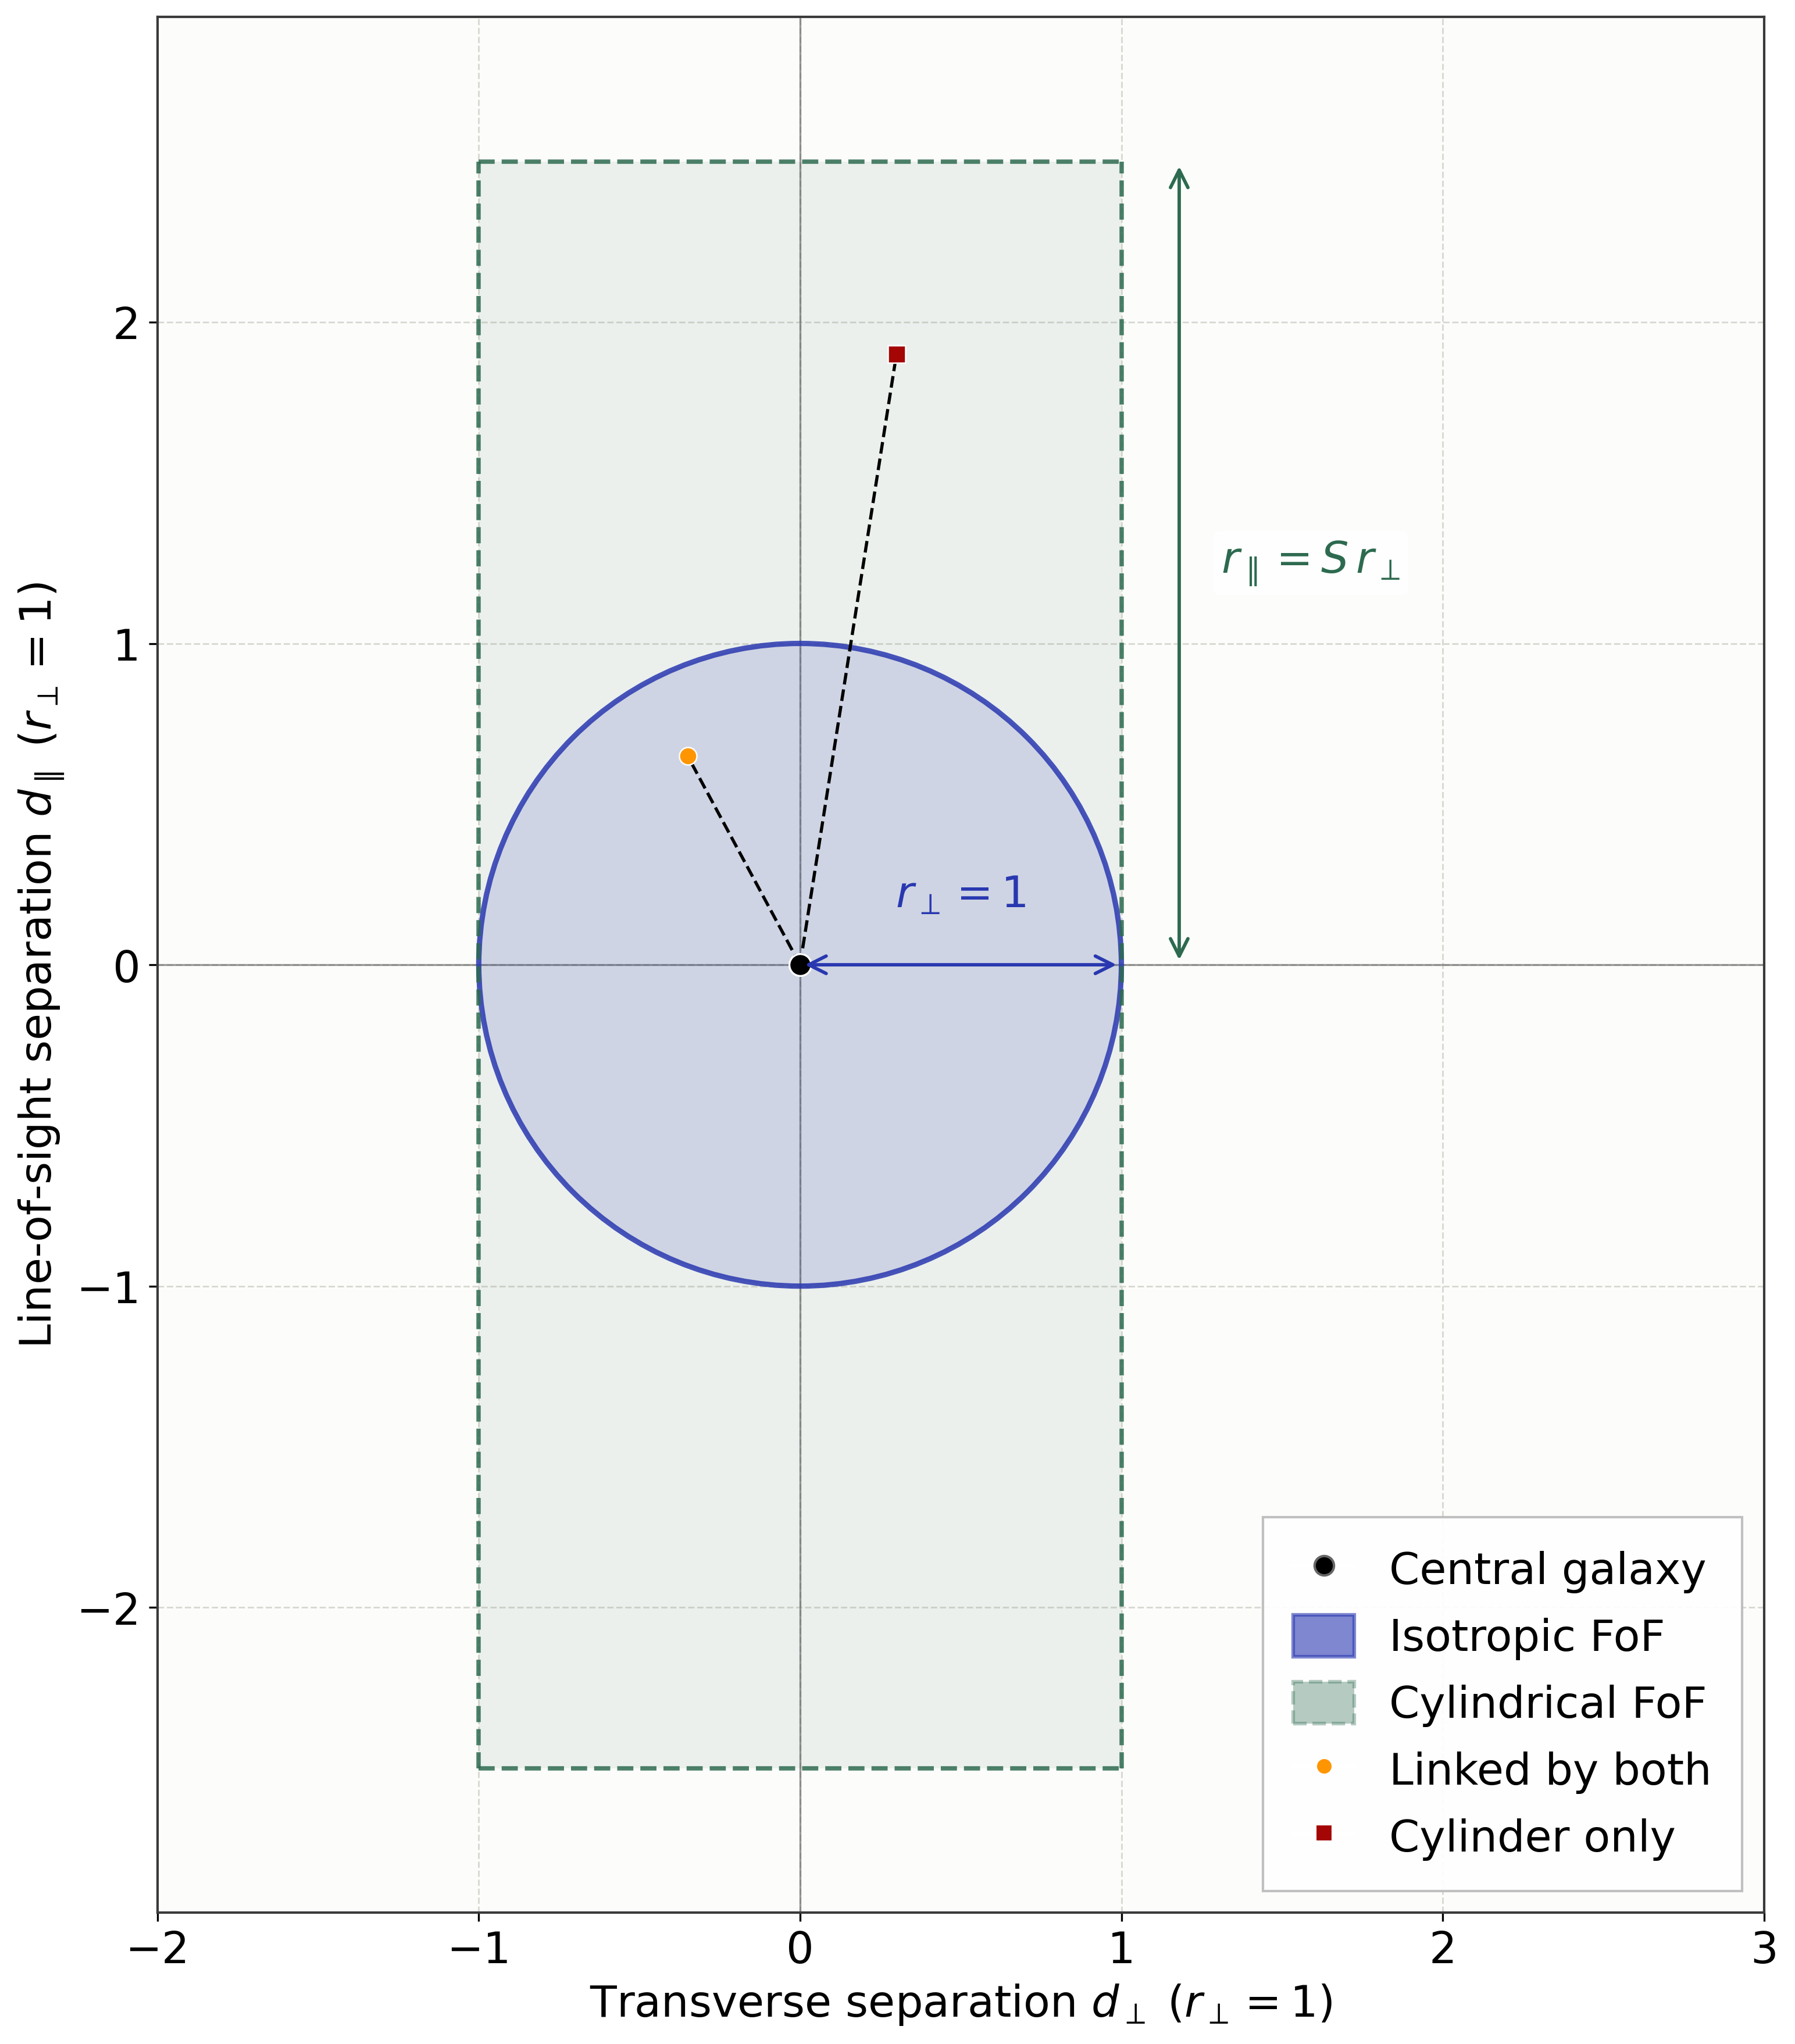

In [6]:
fig, ax = plt.subplots(figsize=(3*COL_W, 1.8*COL_W), dpi=DPI)

# color palettte
C_ISO  = '#2938B0'   # sky blue      — isotropic FoF
C_CYL  = '#2D6A4F'  # vermilion     — cylindrical FoF
C_BOTH = "#FF9500"   # bluish green  — linked by both
C_CONLY= "#A40505"   # orange        — cylinder only
C_GALA = '#000000'   # black         — central galaxy

ax.set_facecolor('#FCFCFB')
for spine in ax.spines.values():
    spine.set_linewidth(1.0)
    spine.set_color('#3A3A3A')

ax.grid(True, color='#D9D9D3', linestyle='--', linewidth=0.7, zorder=0)
ax.set_axisbelow(True)

r_perp_demo = 1.0            # unity — axis labels carry the normalisation note
illustrative_stretch = 2.5   # S=10 in the analysis; 2.5 keeps the diagram legible to fit in the column
r_par_demo  = r_perp_demo * illustrative_stretch
cx = 0.0                     # central galaxy at origin

ax.scatter([cx], [0], s=82, color=C_GALA, edgecolor='white', linewidth=0.8, zorder=6)

circle = patches.Circle((cx, 0), radius=r_perp_demo,
    facecolor=C_ISO, edgecolor='none', alpha=0.15, zorder=3)
ax.add_patch(circle)
circle_edge = patches.Circle((cx, 0), radius=r_perp_demo,
    facecolor='none', edgecolor=C_ISO, alpha=0.85,
    linestyle='-', linewidth=2.2, zorder=4)
ax.add_patch(circle_edge)

rect = patches.Rectangle(
    (cx - r_perp_demo, -r_par_demo), 2 * r_perp_demo, 2 * r_par_demo,
    facecolor=C_CYL, edgecolor='none', alpha=0.08, zorder=2)
ax.add_patch(rect)
for y_edge in [-r_par_demo, r_par_demo]:
    ax.plot([cx - r_perp_demo, cx + r_perp_demo], [y_edge, y_edge],
            color=C_CYL, linewidth=1.8, linestyle='--', alpha=0.85, zorder=5)
for x_edge in [cx - r_perp_demo, cx + r_perp_demo]:
    ax.plot([x_edge, x_edge], [-r_par_demo, r_par_demo],
            color=C_CYL, linewidth=1.8, linestyle='--', alpha=0.85, zorder=5)

ax.scatter([cx - 0.35], [0.65], color=C_BOTH, s=52, zorder=7, marker='o',
           edgecolor='white', linewidth=0.6)
ax.scatter([cx + 0.30], [1.90], color=C_CONLY, s=52, zorder=7, marker='s',
           edgecolor='white', linewidth=0.6)

# Dashed black lines connecting central galaxy to example nodes
ax.plot([cx, cx - 0.35], [0, 0.65], color='black', linestyle='--', linewidth=1.3, zorder=5.5)
ax.plot([cx, cx + 0.30], [0, 1.90], color='black', linestyle='--', linewidth=1.3, zorder=5.5)

label_box = dict(boxstyle='round,pad=0.18', facecolor='white', edgecolor='none', alpha=0.88)

ax.annotate('', xy=(cx + r_perp_demo, 0), xytext=(cx, 0),
            arrowprops=dict(arrowstyle='<->', color=C_ISO, lw=1.4), zorder=8)
ax.text(cx + r_perp_demo / 2, 0.15, r'$r_\perp = 1$', ha='center', va='bottom',
        color=C_ISO, fontweight='bold')

r_par_x = cx + r_perp_demo + 0.18
ax.annotate('', xy=(r_par_x, r_par_demo), xytext=(r_par_x, 0),
            arrowprops=dict(arrowstyle='<->', color=C_CYL, lw=1.4), zorder=8)
ax.text(r_par_x + 0.13, r_par_demo / 2, r'$r_\parallel = S\,r_\perp$',
        va='center', ha='left', color=C_CYL, fontweight='bold',
        bbox=label_box)
legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=C_GALA,
           markeredgecolor='#666666', markersize=8, label='Central galaxy'),
    Patch(facecolor=C_ISO, edgecolor=C_ISO, alpha=0.6,
           linewidth=1.5, label='Isotropic FoF'),
    Patch(facecolor=C_CYL, edgecolor=C_CYL, alpha=0.35,
           linewidth=1.5, linestyle='--', label='Cylindrical FoF'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=C_BOTH,
           markeredgecolor='white', markersize=7, label='Linked by both'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor=C_CONLY,
           markeredgecolor='white', markersize=7, label='Cylinder only'),
]
ax.legend(handles=legend_handles, loc='lower right',
          framealpha=0.92, edgecolor='#BBBBBB',
          fancybox=False, handlelength=1.4, handleheight=1.1,
          borderpad=0.7, labelspacing=0.5)

ax.set_xlim(-2, 3)
ax.set_ylim(-r_par_demo * 1.18, r_par_demo * 1.18)
ax.set_aspect('equal', adjustable='box')
ax.axhline(0, color='#4A4A4A', linewidth=0.8, linestyle='-', alpha=0.55)
ax.axvline(0, color='#4A4A4A', linewidth=0.8, linestyle='-', alpha=0.55)

ax.set_xlabel(r'Transverse separation $d_\perp$ ($r_\perp = 1$)')
ax.set_ylabel(r'Line-of-sight separation $d_\parallel$ ($r_\perp = 1$)')

plt.tight_layout()
plt.savefig('../Report/figures/imp.pdf', bbox_inches='tight', dpi=DPI)
plt.show()

### 2.2 Percolation analysis

The transverse linking length $r_\perp$ is varied to compute two independent topological observables:

**Susceptibility:**

$$
\chi(r_\perp) \;=\; \frac{1}{N} \sum_{s \neq \text{GCC}} s^2 \, n_s ,
$$

where $s$ is the component size, $n_s$ is the number of components of that size, and $N$ is the total number of galaxies. The sum excludes the Giant Connected Component (GCC). The susceptibility $\chi$ is maximized at the percolation threshold, $r_{\rm critical}$, where a single cluster first spans the volume.

**Maximum fragmentation:**

To identify individual galaxy groups rather than superclusters, the network should be at its most fragmented state. The number of valid groups is:

$$
N_{\rm groups}(r_\perp) \;=\; |\{\, c \in G_r \mid 2 \leq |c| < |\text{GCC}| \,\}|.
$$

This counts components that are neither singletons nor the GCC. The peak of $N_{\rm groups}$ occurs at the scale where the network contains the largest number of distinct groups, immediately before they merge into the percolating structure. This scale is defined as $r_{\rm groups}$ (or $r_{\rm link}$).

**Comparison of scales:**
$r_{\rm critical}$ is the percolation threshold, corresponding to the formation of clusters and superclusters. This scale is too large for group identification. It serves as an upper bound to ensure the chosen linking length is sub-critical ($r_{\rm groups} < r_{\rm critical}$).

In [7]:
# Sweep r_perp and compute susceptibility and fragmentation count simultaneously
r_perp_values = np.arange(0.1, 2.5, 0.02)
susceptibilities = []
gcc_percentages = []
num_valid_groups = []
for r_perp in r_perp_values:
    edges = get_cylindrical_edges(r_perp, stretch_factor, coordinates, tree)
    # Build temporary graph to find connected components at this linking length
    temp_graph = nx.Graph()
    temp_graph.add_nodes_from(range(number_of_galaxies))
    temp_graph.add_edges_from(edges)
    components = list(nx.connected_components(temp_graph))

    gcc_size = max(len(c) for c in components)
    # Count components with 2 <= size < GCC size (valid groups)
    valid_groups = [c for c in components if len(c) >= 2 and len(c) < gcc_size]
    num_valid_groups.append(len(valid_groups))

    finite_components = [c for c in components if len(c) < gcc_size]
    gcc_percentages.append(100 * gcc_size / number_of_galaxies)

    if not finite_components:
        susceptibilities.append(0)
        continue

    chi = sum(len(c)**2 for c in finite_components) / number_of_galaxies
    susceptibilities.append(chi)

r_critical_perp = r_perp_values[np.argmax(susceptibilities)]
r_groups_perp = r_perp_values[np.argmax(num_valid_groups)]

print(f"Topological Percolation Threshold (Perp): {r_critical_perp:.2f} h^-1 Mpc")
print(f"Topological Group Threshold (Perp): {r_groups_perp:.2f} h^-1 Mpc")
print(f"Implied Line-of-Sight Threshold (Par): {r_groups_perp * stretch_factor:.2f} h^-1 Mpc")

Topological Percolation Threshold (Perp): 1.34 h^-1 Mpc
Topological Group Threshold (Perp): 0.54 h^-1 Mpc
Implied Line-of-Sight Threshold (Par): 5.40 h^-1 Mpc


### 2.3 Linking parameter $b$

In FoF studies, the linking length is often expressed as a dimensionless ratio:

$$
b \equiv \frac{r_{\rm link}}{\bar{d}}, \qquad \bar{d} = n^{-1/3}, \qquad
n = \frac{N_{\rm gal}}{V_{\rm shell}},
$$

where $\bar{d}$ is the mean inter-galaxy spacing and $n$ is the number density. 

Literature values for $b$ vary by calibration. Davis et al. (1985) used $b \in [0.14, 0.20]$, while the redshift-dependent linking length in Tempel et al. (2014) corresponds to $b \approx 0.113$ to $0.115$ for the $0.02 \leq z \leq 0.06$ slice. The parameter $b$ is calculated here as a post-hoc check on the topologically derived $r_{\rm groups}$.

**Sample volume:** The volume-limited slice occupies a spherical shell between the comoving distances at $z_{\min}$ and $z_{\max}$, restricted to the SDSS footprint:

$$
V_{\rm shell} \;=\; \frac{4\pi}{3}\,(d_{\max}^{3} - d_{\min}^{3}) \,\cdot\, f_{\rm sky},
\qquad f_{\rm sky} = \frac{7221\,{\rm deg}^2}{41252.96\,{\rm deg}^2}.$$

The SDSS MGS footprint area is approximately $7221\,\mathrm{deg}^2$.

In [8]:
SDSS_sky_fraction = 7221 / 41252.96
d_min = cosmo.comoving_distance(z_min).value 
d_max = cosmo.comoving_distance(z_max).value 
limited_volume = (4/3) * np.pi * (d_max**3 - d_min**3) * SDSS_sky_fraction
number_density = number_of_galaxies / limited_volume
d_mean = number_density**(-1/3)
b = r_groups_perp / d_mean
print(f"\nLinking parameter b = {b:.3f}")
print(f"Tempel comparison : b ≈ 0.113–0.115")
print(f"Classical FoF range (Davis 1985, Berlind 2006): 0.14 < b < 0.20")


Linking parameter b = 0.144
Tempel comparison : b ≈ 0.113–0.115
Classical FoF range (Davis 1985, Berlind 2006): 0.14 < b < 0.20


### 2.4 GCC diagnostic

The GCC is the largest connected component in the network. As $r_\perp$ increases, the network undergoes a percolation transition, where isolated groups merge into a structure spanning the sampled volume.

Two methods identify this transition: the maximum gradient of the GCC size ($d(\text{GCC})/d r_\perp$) and the maximum susceptibility $\chi$. Both identify the scale at which clusters and superclusters form. Because the network is hierarchical, these methods target a scale larger than that of individual galaxy groups.

The maximum fragmentation criterion isolates the group scale. At $r_{\rm groups}$, the network contains the largest number of distinct, finite groups. Any increase in $r_\perp$ beyond this point results in group mergers. By construction, $r_{\rm groups}$ is smaller than the percolation threshold.

The GCC diagnostic plot compares three topological markers:
- **Maximum fragmentation** ($r_{\rm groups}$): the scale for group identification.
- **Susceptibility peak** ($r_{\rm critical}$): the percolation threshold.
- **Maximum gradient**: the steepest growth phase of the supercluster network.

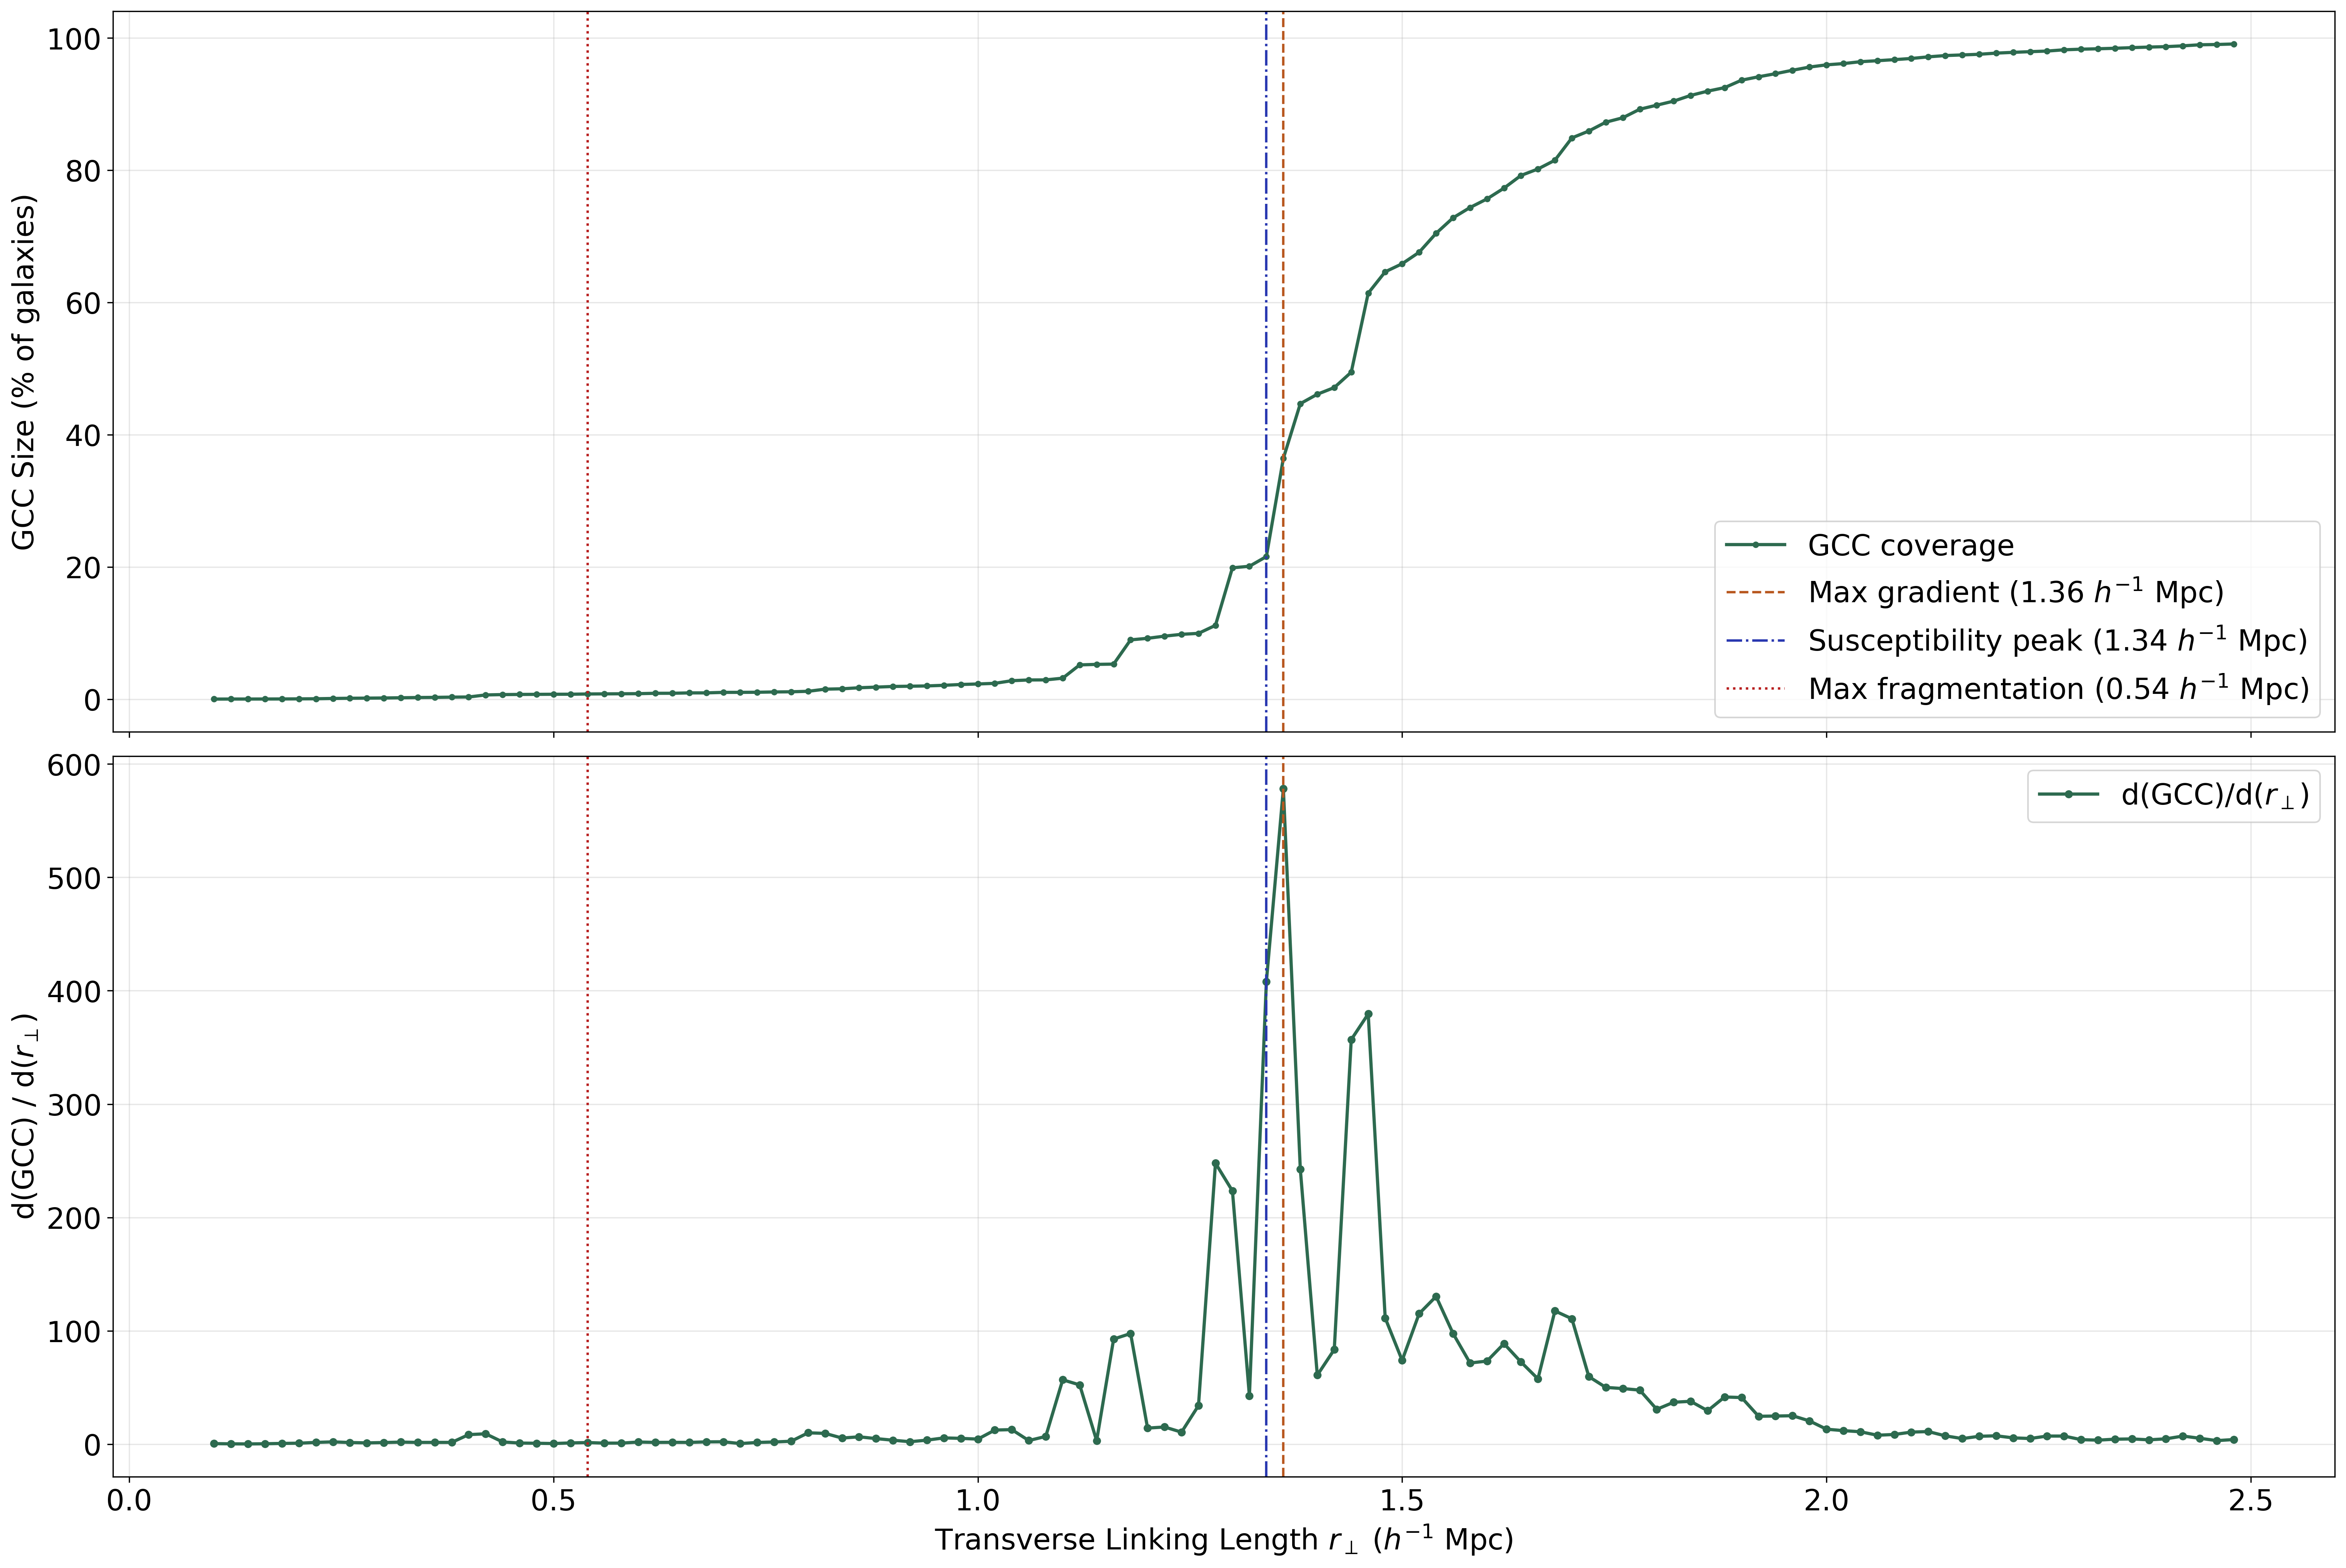

Max gradient r_c:      1.36 h^-1 Mpc
Susceptibility peak (r_critical):    1.34 h^-1 Mpc
Max fragmentation (r_groups):        0.54 h^-1 Mpc


In [9]:
gcc_array = np.array(gcc_percentages)

# Differentiate the GCC curve to locate the maximum growth rate
dgcc = np.gradient(gcc_array, r_perp_values)
r_max_gradient = r_perp_values[np.argmax(dgcc)]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(COL_W * 3, COL_W * 2), dpi=DPI, sharex=True, constrained_layout=True)

# --- Top panel: GCC coverage ---
ax1.plot(r_perp_values, gcc_array, marker='o', markersize=3,
         color='#2D6A4F', linewidth=2, label='GCC coverage')
ax1.axvline(x=r_max_gradient, color='#B85820', linestyle='--',
            label=f'Max gradient ({r_max_gradient:.2f} $h^{{-1}}$ Mpc)')
ax1.axvline(x=r_critical_perp, color="#2938B0", linestyle='-.',
            label=f'Susceptibility peak ({r_critical_perp:.2f} $h^{{-1}}$ Mpc)')
ax1.axvline(x=r_groups_perp, color="#B82020", linestyle=':',
            label=f'Max fragmentation ({r_groups_perp:.2f} $h^{{-1}}$ Mpc)')
ax1.set_ylabel('GCC Size (% of galaxies)')
ax1.legend()
ax1.grid(alpha=0.3)

# --- Bottom panel: gradient of GCC ---
ax2.plot(r_perp_values, dgcc, marker='o', markersize=4,
         color='#2D6A4F', linewidth=2, label=r'd(GCC)/d($r_{\perp}$)')
ax2.axvline(x=r_max_gradient, color='#B85820', linestyle='--')
ax2.axvline(x=r_critical_perp, color="#2938B0", linestyle='-.')
ax2.axvline(x=r_groups_perp, color="#B82020", linestyle=':')
ax2.set_xlabel(r'Transverse Linking Length $r_{\perp}$ ($h^{-1}$ Mpc)')
ax2.set_ylabel(r'd(GCC) / d($r_{\perp}$)')
ax2.legend()
ax2.grid(alpha=0.3)

plt.savefig('../report/figures/GCC_Diagnostic_Cylindrical_r_perp_Scan.pdf', bbox_inches='tight', dpi=DPI)
plt.show()

print(f"Max gradient r_c:      {r_max_gradient:.2f} h^-1 Mpc")
print(f"Susceptibility peak (r_critical):    {r_critical_perp:.2f} h^-1 Mpc")
print(f"Max fragmentation (r_groups):        {r_groups_perp:.2f} h^-1 Mpc")

### 2.5 Building the final graph

With $r_{\rm groups}^\perp$ found by the maximum fragmentation, we build the final graph using the same cylindrical FoF method we used before, run once at the chosen linking length.

In [10]:
# Build the final network at r_groups_perp
final_edges = get_cylindrical_edges(r_groups_perp, stretch_factor, coordinates, tree)
G = nx.Graph()
G.add_nodes_from(range(number_of_galaxies))
G.add_edges_from(final_edges)

print(f"Network built. Nodes: {G.number_of_nodes()} | Edges: {G.number_of_edges()}")

Network built. Nodes: 75042 | Edges: 95310


### 2.6 Group assignment

Connected components of the linking graph are defined as galaxy groups. Two galaxies are members of the same group if they are connected by a chain of pairwise links.

Each component is assigned a unique integer and stored in the MGS table. Every galaxy carries two labels:

- `GroupID`: The reference label from Tempel et al. (2014).
- `Detected_GroupID`: The label derived from this analysis, assigned to all galaxies including singletons.

In [11]:
# Connected components are the groups by definition
groups = list(nx.connected_components(G))
group_labels = np.zeros(len(mgs), dtype=int)
for group_id, members in enumerate(groups):
    for node in members:
        group_labels[node] = group_id

mgs['Detected_GroupID'] = group_labels

## Phase 3: Results

### 3.1 Phase-transition analysis

This figure shows the two topological observables on a shared $r_\perp$ axis:

- **Susceptibility $\chi(r_\perp)$**: peaks at $r_{\rm critical}^\perp$, identifying the percolation threshold.
- **Fragmentation count $N_{\rm groups}(r_\perp)$**: peaks at $r_{\rm groups}^\perp$, where the network contains the maximum number of distinct groups.

The vertical lines identify $r_{\rm critical}^\perp$ and $r_{\rm groups}^\perp$. The choice of $r_{\rm groups}^\perp$ as the group scale is valid because it is sub-critical:

$$
r_{\rm groups}^\perp \;<\; r_{\rm critical}^\perp.$$

If the linking length exceeded the percolation threshold, the analysis would identify filaments and superclusters instead of groups.

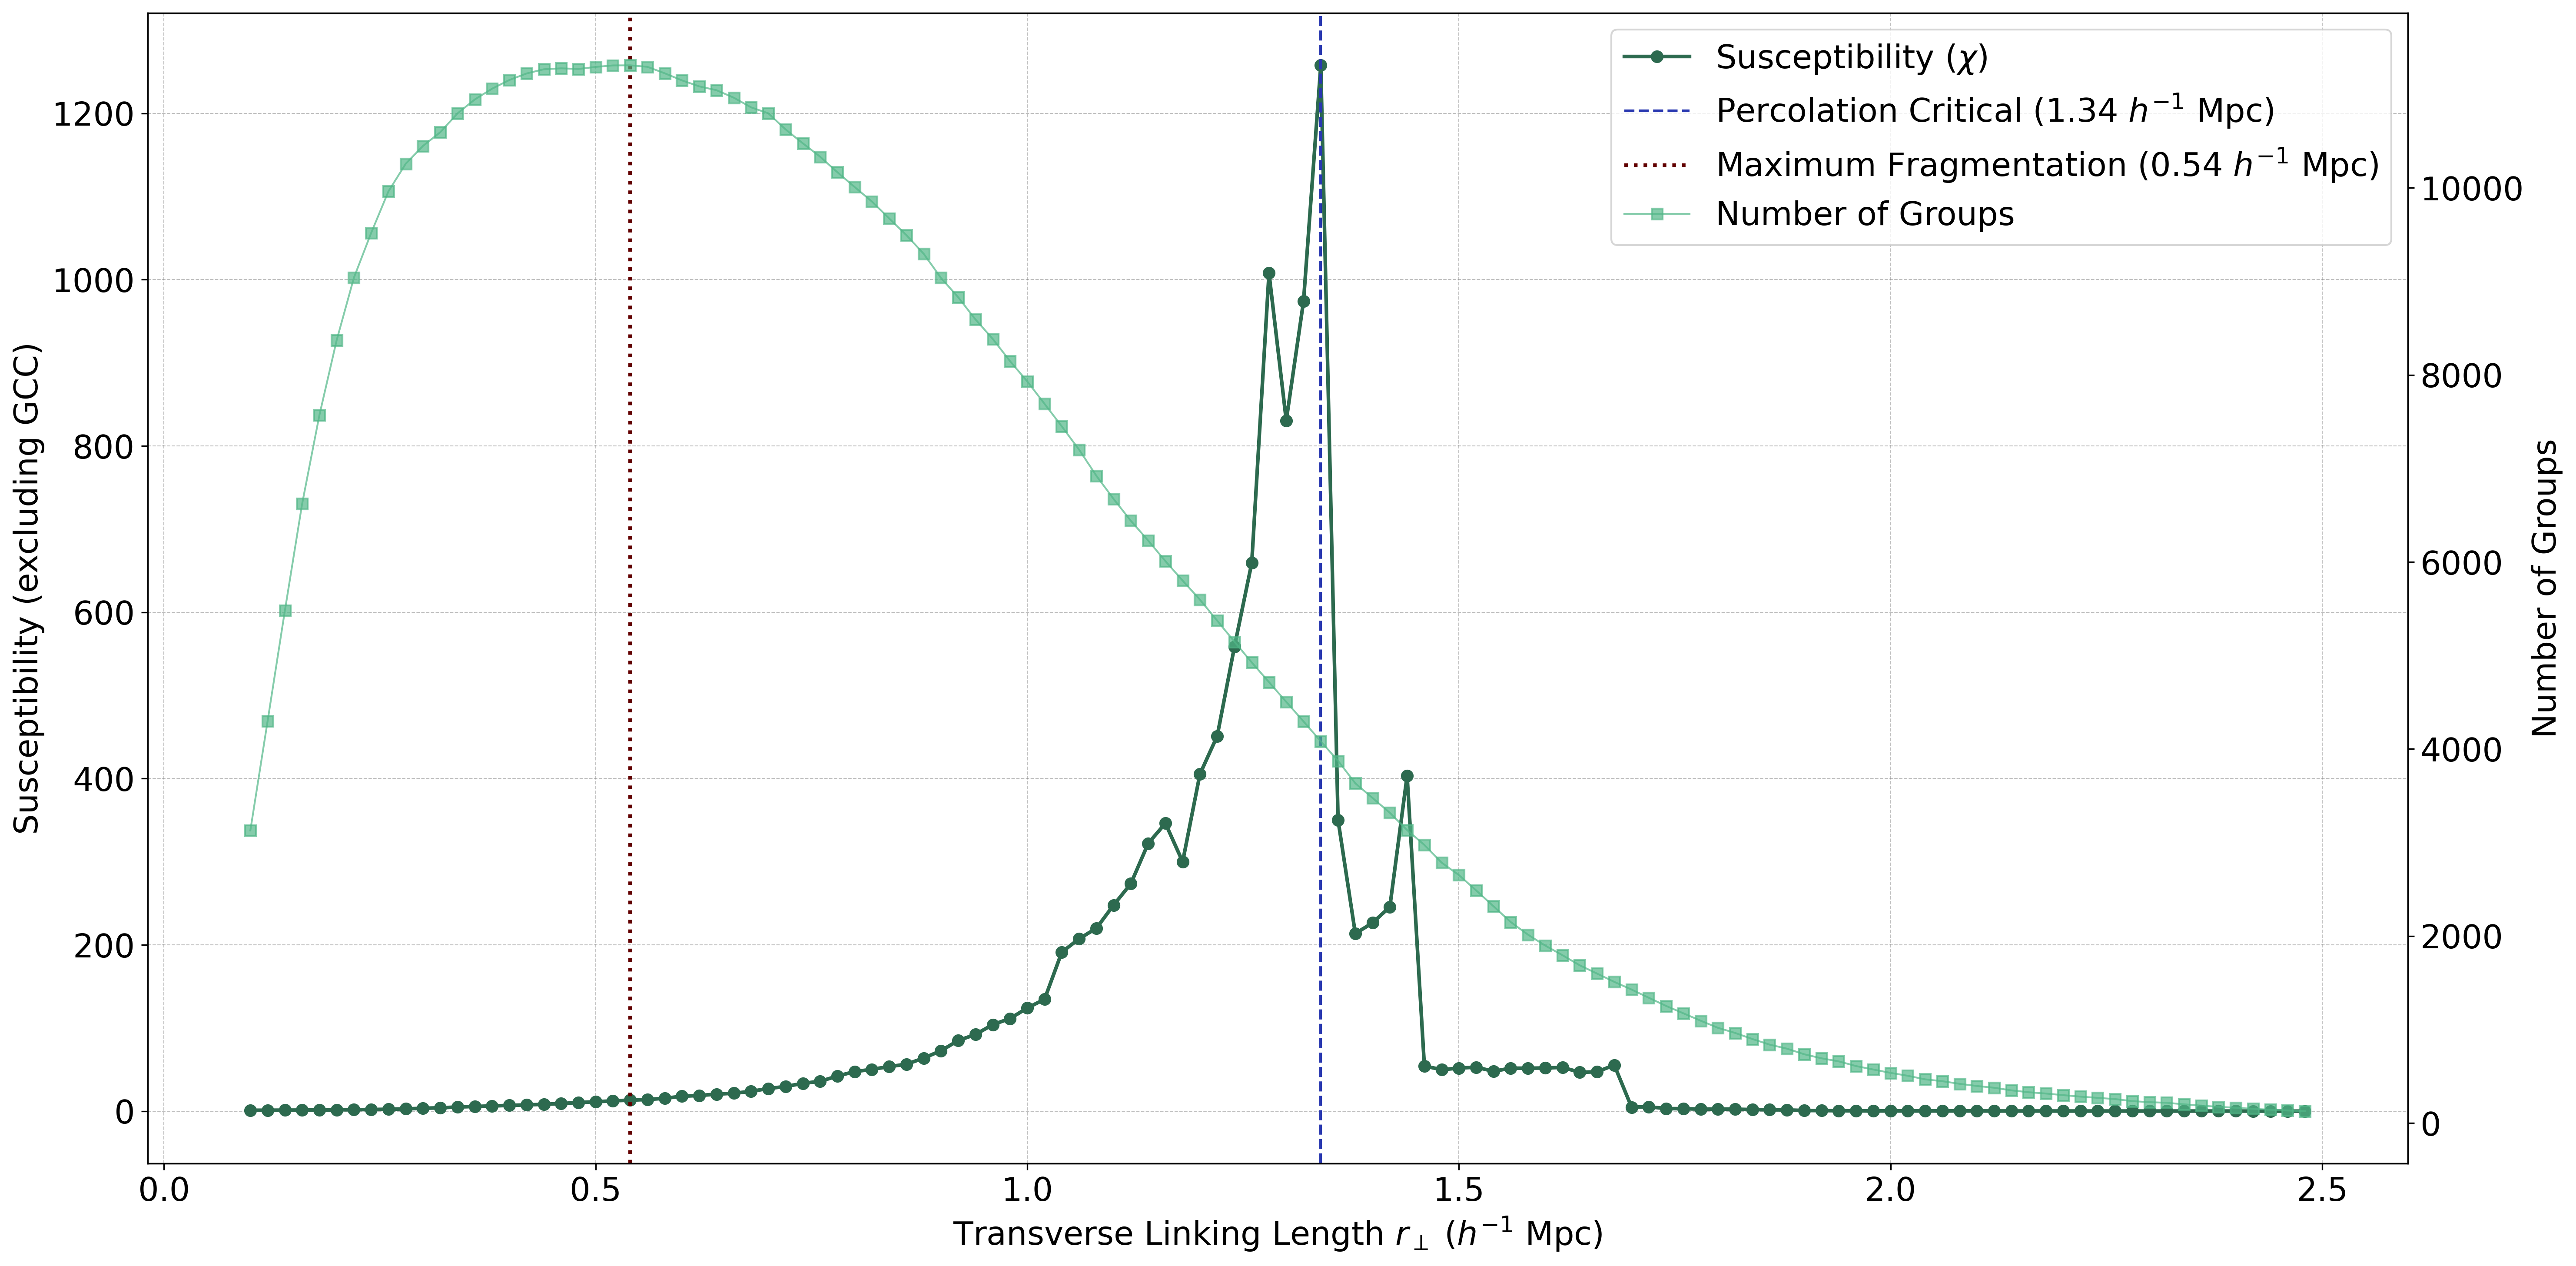

In [12]:
fig, ax1 = plt.subplots(figsize=(COL_W * 3, COL_W * 1.5), dpi=DPI)

# Plot susceptibility
ax1.plot(r_perp_values, susceptibilities, marker='o', linestyle='-', color="#2D6A4F", linewidth=2, label=r'Susceptibility ($\chi$)')

# Mark the critical points
ax1.axvline(x=r_critical_perp, color="#2938B0", linestyle='--', label=f'Percolation Critical ({r_critical_perp:.2f} $h^{{-1}}$ Mpc)')
ax1.axvline(x=r_groups_perp, color="#630000", linestyle=':',linewidth=2, label=f'Maximum Fragmentation ({r_groups_perp:.2f} $h^{{-1}}$ Mpc)')

ax1.set_xlabel(r"Transverse Linking Length $r_{\perp}$ ($h^{-1}$ Mpc)", color='black')
ax1.set_ylabel("Susceptibility (excluding GCC)", color='black')
ax1.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

# Add a twin axis to show the number of groups (maximum fragmentation)
ax2 = ax1.twinx()
ax2.plot(r_perp_values, num_valid_groups, marker='s', linestyle='-', color="#52B788", linewidth=1, alpha=0.7, label='Number of Groups')
ax2.set_ylabel("Number of Groups", color='black')

# Combine legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

plt.tight_layout()
plt.savefig('../report/figures/Anisotropic_Phase_Transition_Cylindrical_r_perp.pdf', bbox_inches='tight', dpi=DPI)
plt.show()

### 3.2 Spatial distribution of groups

To evaluate the uniformity of the group catalogue, galaxies are projected onto the RA–Dec plane in four redshift bins ($\Delta z = 0.01$), shown as the four rows.

Grouped galaxies are colored by Tempel `GroupID` (left column) or `Detected_GroupID` (right column), with marker size proportional to group richness. Field galaxies are shown in grey. A systematic increase in group size with redshift would indicate that the fixed $r_\perp$ is too large at higher distances.

In [ ]:
def make_group_colors(group_ids, seed=0):
    """Stable shuffled qualitative colour map."""
    rng = np.random.default_rng(seed)
    base = plt.cm.tab20(np.linspace(0, 1, 20))
    unique = np.asarray(sorted(group_ids))
    perm = rng.permutation(len(unique))
    return {gid: base[perm[i] % 20] for i, gid in enumerate(unique)}


def plot_radec_panel(ax, mgs, group_col, z_lo, z_hi):
    """One RA-Dec panel, sliced in redshift."""
    slice = mgs[mgs['z'].between(z_lo, z_hi, inclusive='left')]

    counts = slice[group_col].value_counts(dropna=True)
    grouped_ids = counts[counts > 1].index
    is_grouped = slice[group_col].isin(grouped_ids) & slice[group_col].notna()

    grouped = slice[is_grouped]
    isolated = slice[~is_grouped]

    # Field / singleton galaxies trace the cosmic web in the background: small,
    # faint points so the voids and filaments stay visible. rasterized=True
    # bakes the ~75k points into one raster layer instead of individual vector
    # paths, keeping the PDF small.
    ax.scatter(isolated['ra'], isolated['dec'],
               c='0.55', s=1.2, alpha=0.30, linewidths=0, rasterized=True)

    # Grouped galaxies, coloured by group and sized (modestly) by richness so
    # rich systems stand out without smearing into blobs.
    if len(grouped) > 0:
        richness = grouped[group_col].map(counts).astype(float)
        sizes = (3.5 + 1.3 * np.log10(richness)) ** 2
        cmap = make_group_colors(grouped_ids)
        colors = np.array([cmap[g] for g in grouped[group_col].values])
        ax.scatter(grouped['ra'], grouped['dec'],
                   c=colors, s=sizes, alpha=0.85, edgecolors='none',
                   rasterized=True)

    # Equal aspect keeps each panel at the true wide-and-short RA-Dec footprint
    # of the survey slab, so voids, filaments and groupings read correctly.
    ax.set_aspect('equal')
    return len(slice), len(grouped)


# main figure
#
# Layout: the four redshift slabs run down the rows, the two catalogues
# (Tempel | Detected) across the two columns. Each slab is named by a centred
# title above its row; the two catalogue names head the columns once at the top.
# Each panel keeps the true RA-Dec aspect ratio, large enough to resolve the
# cosmic-web structure. The figure is placed full width on a report page.

z_slices = np.arange(z_min, z_max + 1e-9, 0.01)   # [0.02, 0.03, 0.04, 0.05, 0.06]
n_bins = len(z_slices) - 1                          # 4 bins

fig, axes = plt.subplots(n_bins, 2,
                         figsize=(COL_W * 2.5, COL_W * 2.45),
                         constrained_layout=True,
                         sharex=True, sharey=True)

for row, (z_lo, z_hi) in enumerate(zip(z_slices[:-1], z_slices[1:])):
    plot_radec_panel(axes[row, 0], mgs, group_col='GroupID',          z_lo=z_lo, z_hi=z_hi)
    plot_radec_panel(axes[row, 1], mgs, group_col='Detected_GroupID', z_lo=z_lo, z_hi=z_hi)

# Column headers: the two catalogues, once at the top.
axes[0, 0].set_title('Tempel et al. 2014', fontweight='bold')
axes[0, 1].set_title('Detected', fontweight='bold')

# Axis labels: Dec on left column, RA on bottom row
for row in range(n_bins):
    axes[row, 0].set_ylabel('Dec [deg]')
axes[n_bins - 1, 0].set_xlabel('RA [deg]')
axes[n_bins - 1, 1].set_xlabel('RA [deg]')

# Row labels: redshift slab on the right side of each row's right panel.
# rotation=0 keeps the text horizontal; yaxis.set_label_position('right')
# places it outside the right edge — no overlap, no gap needed.
for row, (z_lo, z_hi) in enumerate(zip(z_slices[:-1], z_slices[1:])):
    axes[row, 1].set_ylabel(f'$z \\in [{z_lo:.2f},\\ {z_hi:.2f})$',
                            rotation=90, ha='center', va='center', labelpad=6)
    axes[row, 1].yaxis.set_label_position('right')

plt.savefig('../report/figures/Galaxy_distribution_and_groups_in_RA_Dec_detected_vs_Tempel_2014_per_redshift_bin.pdf', bbox_inches='tight', dpi=DPI)
plt.show()


### 3.3 Group richness distribution

The richness distribution is compared between the detected catalogue and Tempel et al. (2014) using a log-log histogram. Both distributions are restricted to $N \geq 2$. 

Two potential failure modes are identified:

- **Over-merging:** A shift toward higher $N$ would indicate that small groups are incorrectly connected into larger structures.
- **Fragmentation:** A shift toward lower $N$ would suggest that rich clusters are split, possibly because the linking cylinder or stretch factor is too small to account for the velocity dispersion.

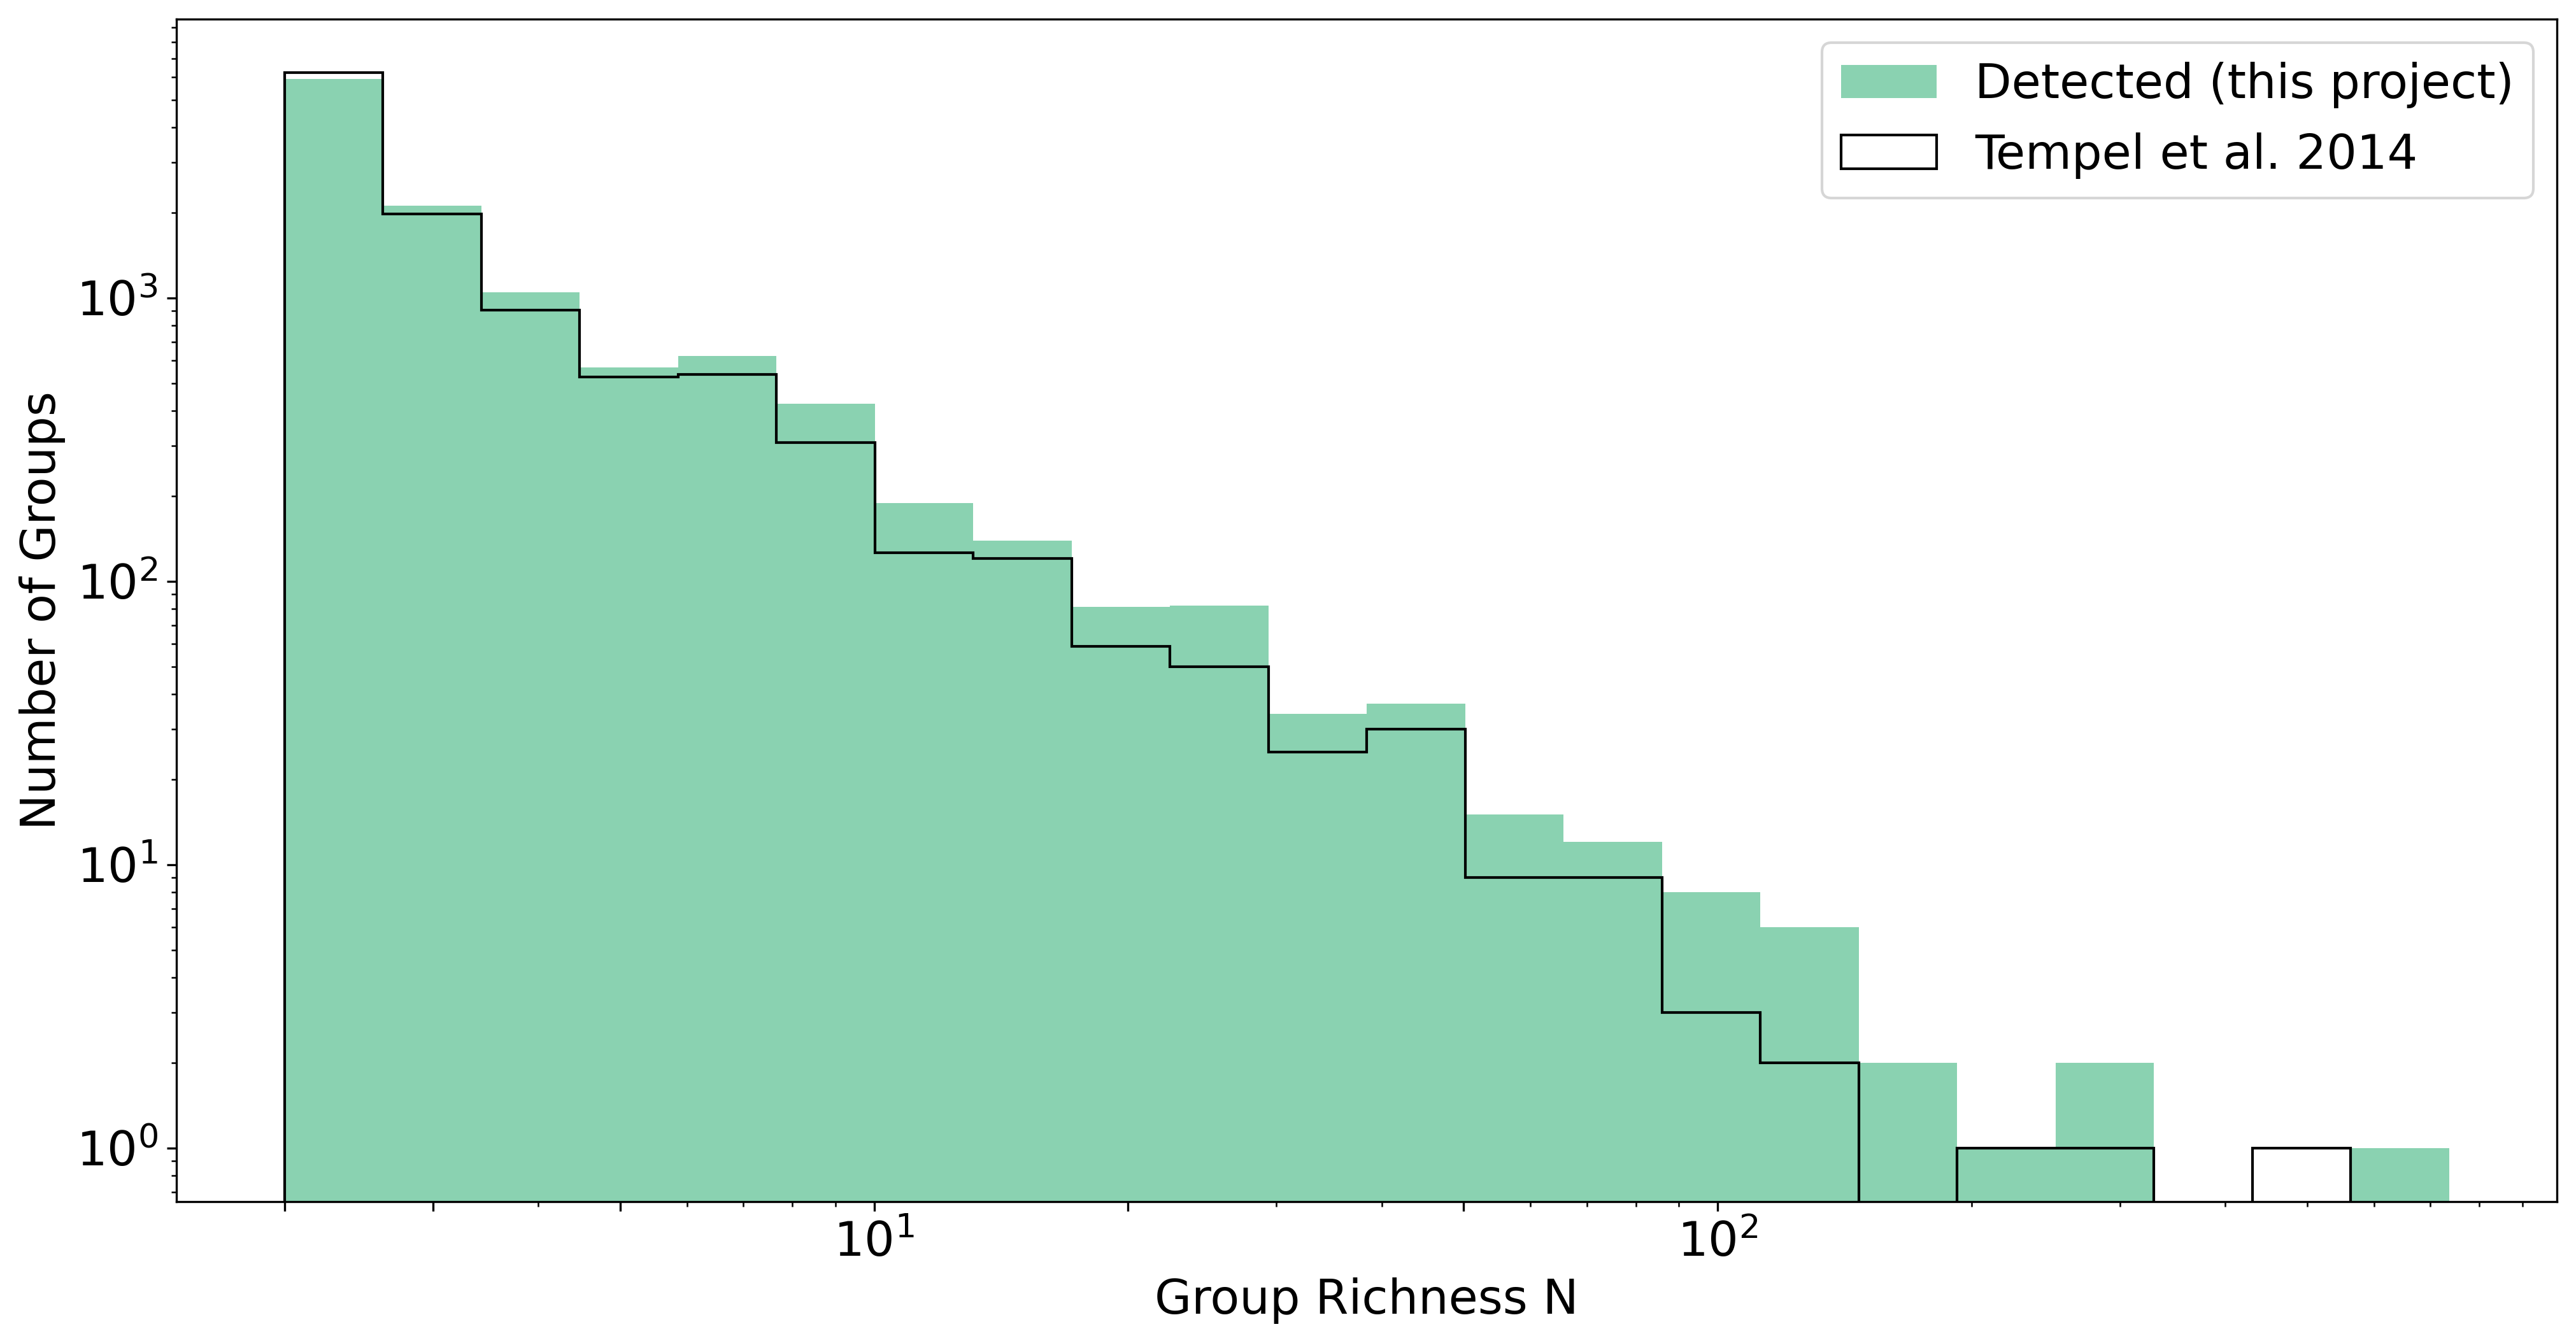

In [14]:
detected_sizes = mgs['Detected_GroupID'].value_counts()
detected_sizes = detected_sizes[detected_sizes >= 2]  # Restrict to groups with at least 2 members

tempel_sizes = mgs['GroupID'].value_counts()
tempel_sizes = tempel_sizes[tempel_sizes >= 2]  # Restrict to groups with at least 2 members
plt.figure(figsize=(COL_W * 2.4, COL_W * 1.2), dpi=DPI)
N_max = max(detected_sizes.max(), tempel_sizes.max())
bins = np.logspace(np.log10(2), np.log10(N_max)+0.1, 23)
plt.hist(detected_sizes, bins=bins, alpha=.7, histtype='stepfilled', label='Detected (this project)', color="#58BF91")
plt.hist(tempel_sizes, bins=bins, histtype='step', label='Tempel et al. 2014', color="#000000")
plt.yscale('log')
plt.xscale('log')
plt.xticks([2, 3, 5, 10, 20, 50, 100])

plt.xlabel('Group Richness N')
plt.ylabel('Number of Groups')
plt.legend()
plt.savefig('../report/figures/Group_Richness_Distribution.pdf', bbox_inches='tight', dpi=DPI)
plt.show()

## Phase 4: Validation & Assessment

### 4.1 Completeness and purity by richness

For each group in the Tempel et al. (2014) catalog ($N \geq 2$), we identify the detected component with the largest overlap and calculate two metrics:

$$
\text{Completeness} = \frac{|T \cap D|}{|T|}, \qquad
\text{Purity} = \frac{|T \cap D|}{|D|},$$

where $T$ is the set of Tempel members and $D$ is the best-matching detected group. Completeness measures the fraction of a reference group recovered, while purity measures the fraction of the detected group that is genuine.

The results are binned by richness. The expected pattern is high completeness across all bins, with purity declining at high $N$. Because rich clusters have high velocity dispersions, the fixed stretch factor may not fully capture the line-of-sight extent of the most massive systems.

In [15]:
results = []
for true_id in mgs['GroupID'].dropna().unique():
    true_members = set(mgs[mgs['GroupID'] == true_id].index)
    if len(true_members) < 2:
        continue
    
    # Identify the detected group with the most overlap
    detected_ids = mgs.loc[list(true_members), 'Detected_GroupID']
    best_detected = detected_ids.value_counts().index[0]
    detected_members = set(mgs[mgs['Detected_GroupID'] == best_detected].index)
    
    overlap = len(true_members & detected_members)
    completeness = overlap / len(true_members)
    purity = overlap / len(detected_members)
    
    results.append({
        'True_GroupID': true_id,
        'N_true': len(true_members),
        'Completeness': completeness,
        'Purity': purity
    })

validation_df = pd.DataFrame(results)
print(validation_df.groupby(pd.cut(validation_df['N_true'],
      bins=[1,2,5,10,50,500]), observed=False)[['Completeness','Purity']].mean())

           Completeness    Purity
N_true                           
(1, 2]         0.994617  0.824064
(2, 5]         0.992337  0.804612
(5, 10]        0.984191  0.778304
(10, 50]       0.983937  0.757173
(50, 500]      0.988517  0.752681


### 4.1b Completeness and purity by redshift

The matched-group analysis is repeated with binning by mean group redshift. A decrease in purity with redshift would indicate that the transverse linking length $r_\perp$ is too large at higher distances, leading to the merging of physically separate groups. A decrease in completeness would suggest the linking cylinder is too small to capture the velocity spread at higher $z$.

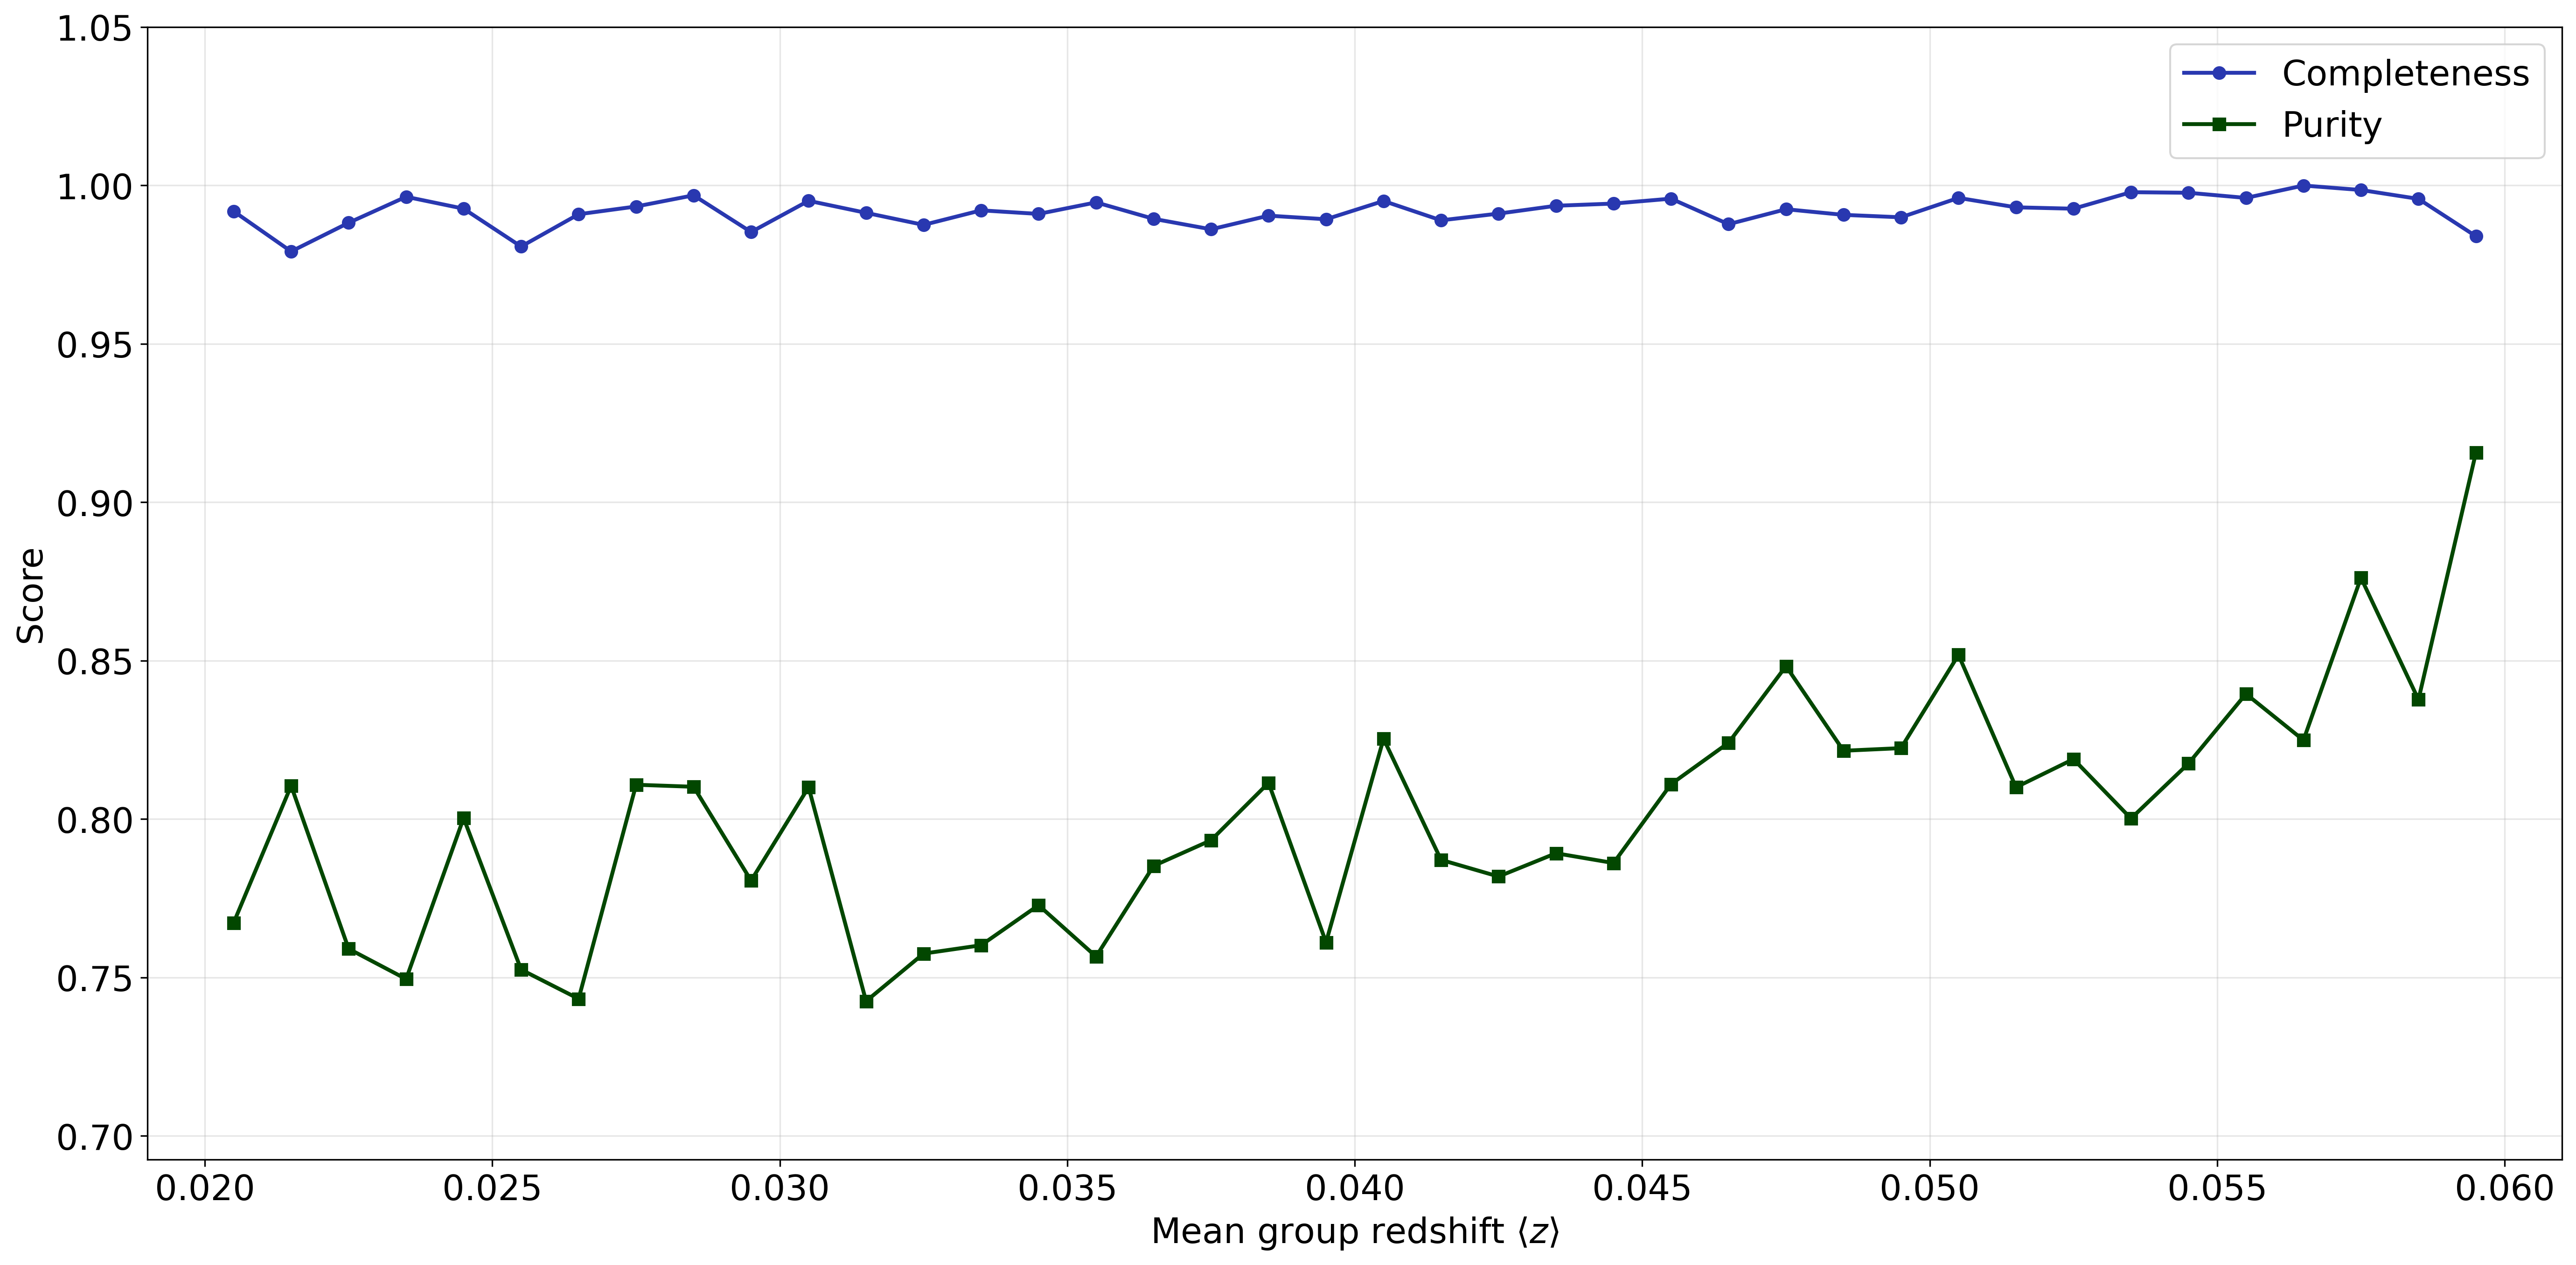

In [16]:
# Map mean redshift onto each true group
group_z_mean = (
    mgs[mgs['GroupID'].notna()]
    .groupby('GroupID')['z']
    .mean()
    .rename('z_mean')
)
validation_df['z_mean'] = validation_df['True_GroupID'].map(group_z_mean)

# Bin by redshift (40 bins of width 0.001 across the full redshift range)
z_bins = np.arange(z_min, z_max + 1e-9, 0.001)
z_labels = [f'[{z_bins[i]:.3f}, {z_bins[i+1]:.3f})' for i in range(len(z_bins) - 1)]
z_cut = pd.cut(validation_df['z_mean'], bins=z_bins, labels=z_labels)
z_stats = validation_df.groupby(z_cut, observed=False)[['Completeness', 'Purity']].mean()
# Plot
z_centers = 0.5 * (z_bins[:-1] + z_bins[1:])
plt.figure(figsize=(2.8*COL_W ,1.4*COL_W), dpi=DPI)
plt.plot(z_centers, z_stats['Completeness'], marker='o', linewidth=2,
        color='#2938B0', label='Completeness')
plt.plot(z_centers, z_stats['Purity'], marker='s', linewidth=2,
        color="#024700", label='Purity')
plt.xlabel(r'Mean group redshift $\langle z \rangle$')
plt.ylabel('Score')
y_lo = max(0.0, z_stats[['Completeness', 'Purity']].min().min() - 0.05)
plt.ylim(y_lo, 1.05)
plt.xlim(z_min -.001, z_max +.001)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../report/figures/Completeness_and_Purity_by_Redshift_Bin.pdf', bbox_inches='tight', dpi=DPI)
plt.show()

### 4.2 Global partition metrics: ARI, NMI, and Fowlkes-Mallows

We compare the full detected partition against Tempel's catalog using three standard clustering-quality scores. The Adjusted Rand Index (ARI) measures pair-level agreement corrected for chance; Normalized Mutual Information (NMI) quantifies shared information between the two labelings; and the Fowlkes-Mallows score (FM) is the geometric mean of pair precision and recall. All three range from 0 (random) to 1 (perfect agreement).

In [17]:
tempel_in_mgs = mgs[mgs['GroupID'].notna()]['GroupID'].value_counts()
valid_tempel_groups = tempel_in_mgs[tempel_in_mgs >= 2].index
grouped_mask = mgs['GroupID'].isin(valid_tempel_groups)
sub = mgs[grouped_mask].copy()

y_true = sub['GroupID'].astype(int).values
y_pred = sub['Detected_GroupID'].values

ari = adjusted_rand_score(y_true, y_pred)
nmi = normalized_mutual_info_score(y_true, y_pred, average_method='arithmetic')
fm  = fowlkes_mallows_score(y_true, y_pred)

print(f"Galaxies in grouped subsample : {len(sub):,}")
print(f"Unique Tempel groups           : {sub['GroupID'].nunique():,}")
print(f"Unique detected groups         : {sub['Detected_GroupID'].nunique():,}")
print()
print(f"Adjusted Rand Index   (ARI)  = {ari:.4f}")
print(f"Norm. Mutual Info     (NMI)  = {nmi:.4f}")
print(f"Fowlkes-Mallows       (FM)   = {fm:.4f}")

Galaxies in grouped subsample : 41,430
Unique Tempel groups           : 10,907
Unique detected groups         : 9,739

Adjusted Rand Index   (ARI)  = 0.8238
Norm. Mutual Info     (NMI)  = 0.9832
Fowlkes-Mallows       (FM)   = 0.8347


### 4.2b Significance of the agreement (permutation null)

ARI, NMI, and FM quantify *how much* the detected and Tempel partitions agree, but not
whether that agreement is *statistically significant*. We test this with a permutation
null: the detected labels are randomly shuffled (preserving the group-size distribution
but destroying which galaxy belongs to which group) and the ARI is recomputed many
times, building the distribution of agreement expected by chance. Because the ARI is
already chance-corrected, this null is centred at ~0; the observed ARI is then reported
as a z-score and an empirical p-value against it. This is the analogue of a statistical
hypothesis test on the catalogue's validity.

In [18]:
# --- Significance of the partition agreement (permutation null) ----------
# ARI is chance-corrected, so a random relabeling should score ~0. Shuffle the
# detected labels n_perm times, recompute ARI each time, and locate the observed
# ARI relative to that null distribution. (~30 s for n_perm=1000.)
rng     = np.random.default_rng(42)
n_perm  = 1000
null_ari = np.empty(n_perm)
y_shuf   = y_pred.copy()
for i in range(n_perm):
    rng.shuffle(y_shuf)                       # in-place permutation of detected labels
    null_ari[i] = adjusted_rand_score(y_true, y_shuf)

z_ari = (ari - null_ari.mean()) / null_ari.std()
p_emp = (np.sum(null_ari >= ari) + 1) / (n_perm + 1)   # one-sided empirical p-value

print(f"Observed ARI         : {ari:.4f}")
print(f"Null ARI  mean ± std : {null_ari.mean():+.2e} ± {null_ari.std():.2e}")
print(f"Null ARI  max        : {null_ari.max():+.2e}   (over {n_perm} permutations)")
print(f"Z-score vs null      : {z_ari:.1f} sigma")
print(f"Empirical p-value    : < {p_emp:.1e}")

Observed ARI         : 0.8238
Null ARI  mean ± std : -3.69e-06 ± 5.67e-05
Null ARI  max        : +2.14e-04   (over 1000 permutations)
Z-score vs null      : 14520.2 sigma
Empirical p-value    : < 1.0e-03


### 4.3 Pair-level precision, recall, and F1

The pair confusion matrix counts, over all galaxy pairs, how many are co-grouped in both catalogs (TP), co-grouped only in ours (FP), co-grouped only in Tempel's (FN), or separated in both (TN). Pair precision is equivalent to mean purity; pair recall is equivalent to mean completeness. The F1 score is their harmonic mean.

In [19]:
pcm = pair_confusion_matrix(y_true, y_pred)
TN, FP, FN, TP = pcm.ravel()

pair_precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
pair_recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
pair_f1 = (2 * pair_precision * pair_recall / (pair_precision + pair_recall)
                  if (pair_precision + pair_recall) > 0 else 0.0)

print(f"Pair confusion matrix")
print(f"  TP = {TP:,}   FP = {FP:,}")
print(f"  FN = {FN:,}   TN = {TN:,}")
print()
print(f"Pair precision  (≈ purity)       = {pair_precision:.4f}")
print(f"Pair recall     (≈ completeness) = {pair_recall:.4f}")
print(f"Pair F1                          = {pair_f1:.4f}")


Pair confusion matrix
  TP = 773,024   FP = 316,094
  FN = 14,472   TN = 1,715,299,880

Pair precision  (≈ purity)       = 0.7098
Pair recall     (≈ completeness) = 0.9816
Pair F1                          = 0.8238


### 4.4 Network topology

Basic topological properties of the final network at $r_{\rm link}$. The clustering coefficient measures how often two linked galaxies share a common neighbor, compared against the Erdős-Rényi baseline at the same edge density. A ratio far above 1 confirms that the network has the clique-like structure expected of physically virialized groups.

In [20]:
degrees        = np.array([d for _, d in G.degree()])
n_nodes        = G.number_of_nodes()
n_edges        = G.number_of_edges()
p_er           = 2 * n_edges / (n_nodes * (n_nodes - 1))

transitivity   = nx.transitivity(G)
avg_clustering = nx.average_clustering(G)

print(f"Graph summary")
print(f"  Nodes      : {n_nodes:,}")
print(f"  Edges      : {n_edges:,}")
print(f"  Mean degree: {degrees.mean():.2f}  (max: {degrees.max()})")
print()
print(f"Clustering  (ER baseline p = {p_er:.2e})")
print(f"  Transitivity         : {transitivity:.4f}   ratio: {transitivity / p_er:.1f}x")
print(f"  Avg local clustering : {avg_clustering:.4f}   ratio: {avg_clustering / p_er:.1f}x")
print()
n_components = nx.number_connected_components(G)
gcc_size     = max(len(c) for c in nx.connected_components(G))
print(f"Components")
print(f"  Total connected components : {n_components:,}")
print(f"  GCC size                   : {gcc_size:,}  ({100*gcc_size/n_nodes:.1f}% of nodes)")

Graph summary
  Nodes      : 75,042
  Edges      : 95,310
  Mean degree: 2.54  (max: 43)

Clustering  (ER baseline p = 3.39e-05)
  Transitivity         : 0.6458   ratio: 19076.6x
  Avg local clustering : 0.3223   ratio: 9519.9x

Components
  Total connected components : 37,500
  GCC size                   : 585  (0.8% of nodes)


### 4.5 Degree distribution

The degree $k$ of a galaxy is its number of cylindrical-FoF links. The degree distribution $P(k)$ — the fraction of nodes with degree $k$ — is the basic fingerprint of the network's architecture. It is compared against the **Erdős–Rényi null**: a random graph with the same node count and the same mean degree $\langle k \rangle$, whose degree distribution is Poisson,

$$P_{\rm ER}(k) = e^{-\langle k \rangle}\,\frac{\langle k \rangle^{k}}{k!},$$

the sparse, large-$N$ limit of the binomial $\binom{N-1}{k}p^k(1-p)^{N-1-k}$ with $\langle k \rangle \approx p(N-1)$.

Two features separate a spatially structured network from this null:

- **Tail excess.** Real groups host high-degree hubs — the central galaxies of rich clusters (BCGs) — that a Poisson graph of the same mean degree would essentially never produce. A tail lying orders of magnitude above the Poisson curve is the degree-space signature of non-random clustering, the counterpart of the excess clustering coefficient in §4.4.
- **Finite cutoff.** Unlike a scale-free network, an FoF (random geometric) graph caps the degree at the number of galaxies that physically fit inside a linking cylinder. $P(k)$ is therefore heavy-tailed but *truncated*, rather than a pure power law — the cutoff $k_{\max}$ is set by the richest cluster in the volume.

The figure plots $P(k)$ on semi-log axes (to expose the tail against the Poisson null) and on log-log axes (to test for a power-law form). The bulk near $\langle k \rangle$ is expected to track the null; the diagnostic content is in the tail.

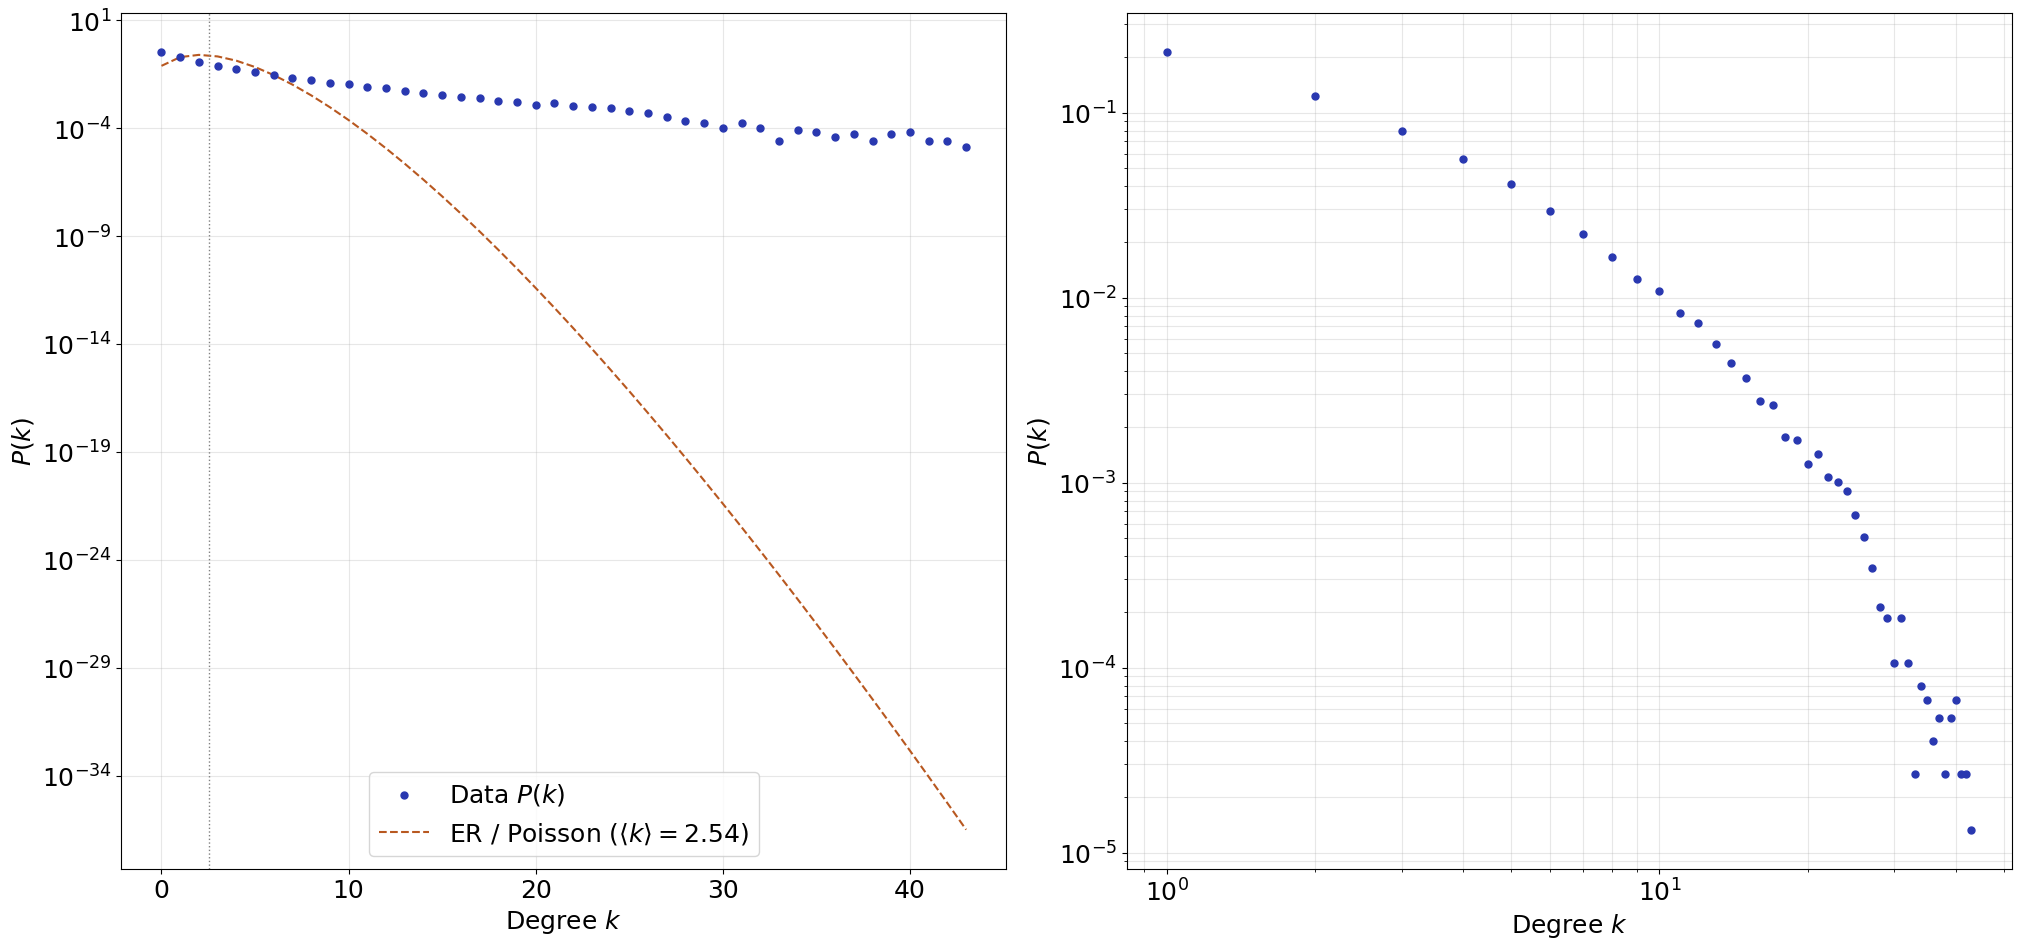

Mean degree         : 2.54
Max degree          : 43
Isolated nodes (k=0): 26,189  (34.9% of nodes)
ER prediction (k=0) : 7.89%  (Poisson, same mean degree)
k=0 vs ER           : 4.4x the ER expectation (over-dense in isolated nodes)


In [21]:
mean_degree = degrees.mean()
k_max       = int(degrees.max())

# Empirical degree distribution P(k), normalised over all nodes (incl. k=0)
k_vals = np.arange(0, k_max + 1)
counts = np.bincount(degrees, minlength=k_max + 1)
pk     = counts / counts.sum()

# ER / Poisson null with the same mean degree
pk_er = poisson.pmf(k_vals, mean_degree)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(COL_W * 3, COL_W*1.4), constrained_layout=True)

# Left: semi-log -- exposes the exponential bulk and any heavy tail
axL.scatter(k_vals, pk, s=25, color='#2938B0', zorder=3, label=r'Data $P(k)$')
axL.plot(k_vals, pk_er, '--', color='#B85820',
         label=fr'ER / Poisson ($\langle k \rangle = {mean_degree:.2f}$)')
axL.axvline(mean_degree, color='grey', ls=':', lw=1)
axL.set_yscale('log')
axL.set_xlabel(r'Degree $k$')
axL.set_ylabel(r'$P(k)$')
axL.legend()
axL.grid(alpha=0.3)

# Right: log-log -- exposes a power-law tail if present (k >= 1 only)
mask = (k_vals >= 1) & (pk > 0)
axR.scatter(k_vals[mask], pk[mask], s=25, color='#2938B0', zorder=3)
axR.set_xscale('log')
axR.set_yscale('log')
axR.set_xlabel(r'Degree $k$')
axR.set_ylabel(r'$P(k)$')
axR.grid(alpha=0.3, which='both')

plt.savefig('../report/figures/Degree_Distribution.pdf', bbox_inches='tight', dpi=DPI)
plt.show()

print(f"Mean degree         : {mean_degree:.2f}")
print(f"Max degree          : {k_max}")
print(f"Isolated nodes (k=0): {counts[0]:,}  ({100 * counts[0] / n_nodes:.1f}% of nodes)")
print(f"ER prediction (k=0) : {100 * pk_er[0]:.2f}%  (Poisson, same mean degree)")
ratio_k0 = pk[0] / pk_er[0]
print(f"k=0 vs ER           : {ratio_k0:.1f}x the ER expectation "
      f"({'over' if ratio_k0 > 1 else 'under'}-dense in isolated nodes)")

### 4.6 Internal structure of the richest detected groups

The global topology of §4.4 averages over 37,500 components. Here the largest detected
groups are profiled individually to see how their internal structure varies. For each
group's induced subgraph we report the number of members $N$, the internal edge density
$2E/N(N-1)$, the internal transitivity, and the diameter (the longest shortest path,
well-defined since every detected group is a connected component by construction). The
giant connected component is expected to be large but loosely knit (low density, larger
diameter — a chain of linked galaxies), whereas a compact virialized cluster should be
denser and more clique-like.

In [22]:
# Internal structure of the largest detected groups 
# value_counts() is sorted descending, so the first entries are the richestgroups;
#  singletons sit far down the list and are excluded.
top_ids = mgs['Detected_GroupID'].value_counts().head(8).index

rows = []
for gid in top_ids:
    nodes = mgs.index[mgs['Detected_GroupID'] == gid].tolist()
    sub   = G.subgraph(nodes)
    n, e  = sub.number_of_nodes(), sub.number_of_edges()
    dens  = 2 * e / (n * (n - 1)) if n > 1 else np.nan
    rows.append({
        'GroupID'     : gid,
        'N'           : n,
        'E'           : e,
        'density'     : dens,
        'transitivity': nx.transitivity(sub),
        'diameter'    : nx.diameter(sub),     # connected by construction
    })

group_struct = pd.DataFrame(rows)
print("Internal structure of the 8 richest detected groups:")
print(group_struct.to_string(index=False,
      formatters={'density': '{:.3f}'.format, 'transitivity': '{:.3f}'.format}))

Internal structure of the 8 richest detected groups:
 GroupID   N    E density transitivity  diameter
     133 585 3633   0.021        0.561        22
       4 302 1721   0.038        0.542        17
       0 301 2114   0.047        0.579        18
    1017 226 1022   0.040        0.615        36
     242 156  554   0.046        0.635        19
     262 154  754   0.064        0.594        17
     251 142  703   0.070        0.612        16
      10 141  827   0.084        0.629        16
